In [1]:
import numpy as np
import pandas as pd
import yaml
from pathlib import Path
import orca

from mazsim import data_loader, variable_loader

In [2]:
project_dir = Path.cwd().parent
orca.add_injectable("project_dir", project_dir)
orca.add_injectable("year",2020)
orca.run(['load_settings','load_data', 'build_networks','register_variables'])

Running step 'load_settings'
Registered injectable: data_dir: data
Registered injectable: output_dir: output
Registered injectable: data_model: data_model.py
Registered injectable: geography_id: maz_id
Registered injectable: base_year: 2020
Registered injectable: end_year: 2050
Registered injectable: calibrated_hh: False
Registered injectable: calibrated_hu: False
Registered injectable: calibrated_jobs: False
Registered injectable: hh_ct_type: subregional
Registered injectable: job_ct_type: subregional
Registered injectable: housing_vacancy_rate: 0.05
Registered injectable: output_tables: ['households', 'persons', 'jobs', 'housing_units']
Registered injectable: custom_steps_dir: configs
Registered injectable: custom_steps_files: ['custom_steps.py']
Registered injectable: custom_variables_dir: configs
Registered injectable: custom_variables_files: ['custom_variables.py']
Registered injectable: submodel_groups: {'hlcm': {'ct_type': 'hh_ct_type', 'calibrated_setting': 'calibrated_hh'}, 'h

In [3]:
from urbansim.models import util
from urbansim_templates import modelmanager as mm
from urbansim_templates.models import LargeMultinomialLogitStep

from urbansim.models.util import (columns_in_filters, columns_in_formula)
from choicemodels.tools import MergedChoiceTable

mm.initialize(Path.joinpath(project_dir, "configs", "submodels"))

Registering model step 'hlcm1'
Registering model step 'hlcm1_calib'
Registering model step 'hlcm2'
Registering model step 'hlcm2_calib'
Registering model step 'hlcm3'
Registering model step 'hlcm3_calib'
Registering model step 'hlcm4'
Registering model step 'hlcm4_calib'
Registering model step 'hulcm1'
Registering model step 'hulcm1_calib'
Registering model step 'hulcm2'
Registering model step 'hulcm2_calib'
Registering model step 'hulcm3'
Registering model step 'hulcm3_calib'
Registering model step 'hupm_rent'
Registering model step 'hupm_value'
Registering model step 'jlcm1'
Registering model step 'jlcm2'
Registering model step 'jlcm3'
Registering model step 'jlcm4'
Registering model step 'jlcm5'


In [4]:
import matplotlib.pyplot as plt
%matplotlib notebook
%matplotlib inline

import seaborn as sb

from bokeh.io import output_notebook#, show
# from bokeh.plotting import Figure
# from datashader.bokeh_ext import create_ramp_legend, create_categorical_legend

output_notebook()

import datashader.transfer_functions as tf

import datashader as ds
from datashader.colors import viridis

def visualize_variable(variable_name):
    p = orca.get_table('blocks').to_frame(['x', 'y', variable_name])
    
    cvs = ds.Canvas(plot_width=1000, plot_height=700)
    agg = cvs.points(p, 'x', 'y', ds.mean(variable_name))
    img = tf.set_background(tf.shade(agg, cmap=viridis),"white")
    return img

def summed_probas(sum_variable, probas):
    p = orca.get_table('blocks').to_frame([sum_variable])
    p['proba'] = probas

    summed_puma = p.groupby(sum_variable).proba.sum()

    (summed_puma / summed_puma.sum()).plot(kind='bar')

def plot_probas(proba):
    p = orca.get_table('blocks').to_frame(['x', 'y'])
    p['proba'] = proba

    cvs = ds.Canvas(plot_width=1000, plot_height=700)
    agg = cvs.points(p, 'x', 'y', ds.mean('proba'))
    img= tf.set_background(tf.shade(agg, cmap=viridis),"white")
    return img

def corr_plot(selected_variables):
    cols = []
    for col in selected_variables:    
        if col.startswith('np'):
            cols.append(col.split('(')[-1][:-1])
        else:
            cols.append(col)

    X = orca.get_table('blocks').to_frame(cols)

    plt.subplots(figsize=(12, 12))
    sb.heatmap(X.corr(), annot=True, cmap="RdYlGn")
    plt.show()
    
def skew_plot(selected_variables):
    cols = []
    for col in selected_variables:    
        if col.startswith('np'):
            cols.append(col.split('(')[-1][:-1])
        else:
            cols.append(col)
            
    X = orca.get_table('blocks').to_frame(cols)
    X.skew().plot(kind='bar')

def create_probs_table(m, rep_chooser_filter = None, sample_alts= None, sample_choosers= None,idx='building_id'):
    filter_cols = columns_in_filters(to_str(m.chooser_filters) + " " + to_str(m.alt_filters) + to_str(rep_chooser_filter))
    colnames = columns_in_formula(m.model_expression) + columns_in_filters(filter_cols)
    alts = orca.get_table(m.alternatives).to_frame(colnames)
    alts = alts.query(to_str(m.alt_filters)) if m.alt_filters else alts
    obs = orca.get_table(m.choosers).to_frame(colnames)
    obs = obs.query(to_str(m.chooser_filters)) if m.chooser_filters else obs
    if idx in obs.columns:
        obs = obs.drop(columns=[idx])
    # Filter representative chooser based on rep_chooser_filter input
    if rep_chooser_filter:
        # check if rep_filter has columns from the interaction terms
        if (all(x in obs.columns for x in columns_in_filters(to_str(rep_chooser_filter)))):
            obs = obs.query(to_str(rep_chooser_filter))
        else:
            chooser_vars = [x for x in columns_in_formula(m.model_expression) if x in orca.get_table(m.choosers).columns]
            raise ValueError("Representative choosers' filters must be on these columns:\n *{}".format('\n *'.join(chooser_vars)))
    if sample_choosers:
        if sample_choosers <= len(obs):
            obs = obs.sample(n= sample_choosers)
        else:
            obs
    if len(obs) == 0:
        raise ValueError('No choosers left after filtering.')
    if len(alts) == 0:
        raise ValueError('No alternatives left after filtering.')
    
    if not sample_alts:
        sample_alts = len(alts)
    mtc = MergedChoiceTable(obs, alts, sample_size= sample_alts)
    probas = m.model.probabilities(mtc)
    probas = probas.reset_index(level=1).groupby(idx).sum()
    return probas

def to_str(w):
    if isinstance(w, str):
        return w
    if isinstance(w, list):
        return ' & '.join(w) if len(w) > 1 else w[0]
    if not w:
        return " "

Loading BokehJS ...

Disaggregating prop_worker_aggr_occ_1 to blocks from block_groups
Disaggregating block_group_id to persons from blocks
Disaggregating maz_id to persons from households
Calculating proportion worker_aggr_occ 1.0 for block_groups
Calculating number of persons for block_groups


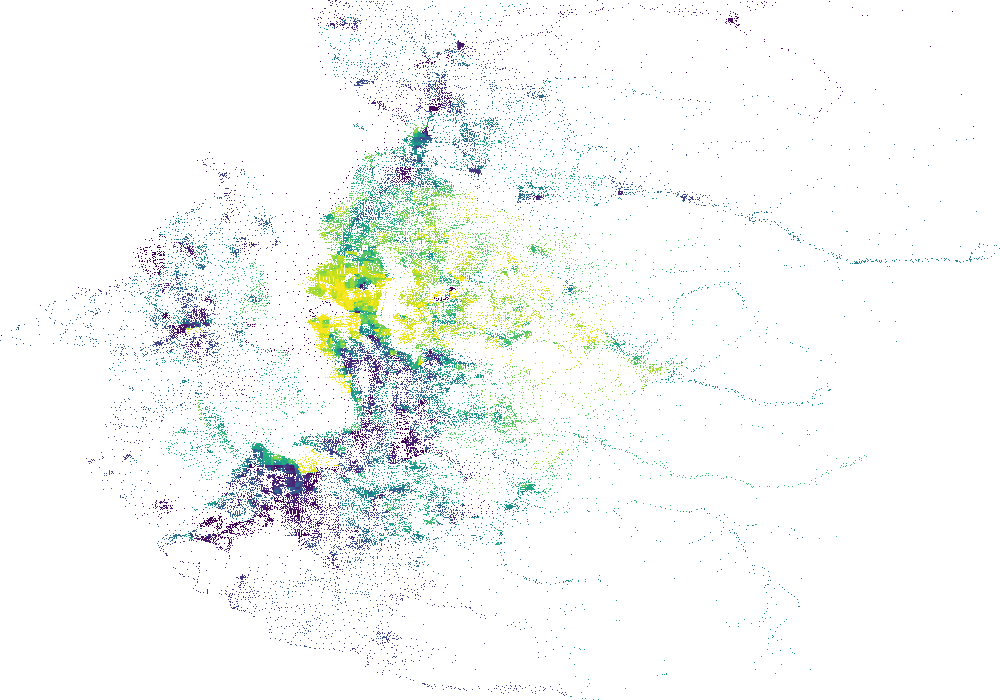

In [7]:
visualize_variable('st_block_groups_prop_worker_aggr_occ_1')

In [ ]:
from pathlib import Path

import orca
import pandas as pd

from mazsim.config import load_yaml

# Longest first, so st_ln_ is stripped before st_.
VARIANT_PREFIXES = ("st_ln_", "ln_", "st_")


def original_name(column):
    """The variable a variant column name was derived from, or None if the name is an original."""
    for prefix in VARIANT_PREFIXES:
        if column.startswith(prefix):
            return column[len(prefix):]
    return None


def build_variable_catalog():
    """One row per original variable per registered table, naming its st_/ln_/st_ln_ variants.

    Names come from orca's registry only, so no variable gets evaluated and pandana columns
    are never computed. Which table gets variants, and which columns are skipped, is read
    from the transforms section of variables.yaml.
    """
    project_dir = Path(orca.get_injectable("project_dir"))
    transforms = load_yaml("variables.yaml", project_dir)["transforms"]
    transform_table = transforms["table"]
    skip_prefixes = tuple(transforms["skip_prefixes"])
    skip_suffixes = tuple(transforms["skip_suffixes"])

    rows = []
    for table_name in sorted(orca.list_tables()):
        # set(): a registered column can share a name with a local one (obs_*), and orca
        # reports both, which would otherwise duplicate rows
        columns = sorted(set(orca.get_table(table_name).columns))
        column_set = set(columns)

        for column in columns:
            original = original_name(column)
            if original is not None:
                if original in column_set:
                    continue  # already recorded on its original's row
                rows.append({
                    "table": table_name,
                    "variable": column,
                    "st_variable": "",
                    "ln_variable": "",
                    "st_ln_variable": "",
                    "note": f"variant of {original}, which is not registered on {table_name}",
                })
                continue

            if table_name != transform_table:
                note = f"variants are only registered on {transform_table}"
            elif column.startswith(skip_prefixes) or column.endswith(skip_suffixes):
                # matches the skip test in variable_loader.register_log_and_standardized_variables
                note = "variants skipped by the transforms section of variables.yaml"
            else:
                note = ""

            rows.append({
                "table": table_name,
                "variable": column,
                "st_variable": f"st_{column}" if f"st_{column}" in column_set else "",
                "ln_variable": f"ln_{column}" if f"ln_{column}" in column_set else "",
                "st_ln_variable": f"st_ln_{column}" if f"st_ln_{column}" in column_set else "",
                "note": note,
            })

    return pd.DataFrame(rows)


variable_catalog = build_variable_catalog()

catalog_path = Path(orca.get_injectable("project_dir")) / "output" / "variable_catalog.csv"
variable_catalog.to_csv(catalog_path, index=False)

counts = variable_catalog.groupby("table").size().sort_values(ascending=False)
print(f"{len(variable_catalog):,} variables across {len(counts)} tables -> {catalog_path}")
print(counts.to_string())


3,820 variables across 20 tables -> c:\Users\jkolberg\PythonProjects\PSRC\psrc_mazsim\projects\baseline_fall_2026\output\variable_catalog.csv
table
blocks                             3012
zones                               184
block_groups                        175
tracts                              175
counties                            175
households                           22
persons                              22
housing_units                        15
jobs                                  7
housing_unit_calib_targets            4
edges                                 4
household_calib_targets               4
observed_data                         4
urban_centers                         3
annual_household_control_totals       3
annual_job_control_totals             3
transit_stops                         3
block_capacity                        2
nodes                                 2
travel_data                           1


In [ ]:
orca.get_table('blocks').to_frame(['industry','prop_worker_aggr_sector_1'])

Disaggregating maz_id to persons from households
Calculating proportion worker_aggr_sector 1.0 for blocks
Calculating number of persons for blocks


,prop_worker_aggr_sector_1
maz_id,
1,0.000000
2,0.016393
3,0.023529
4,0.000000
5,0.000000
...,...
54482,0.000000
54483,0.000000
54484,0.000000


Calculating proportion tenure 2 for blocks


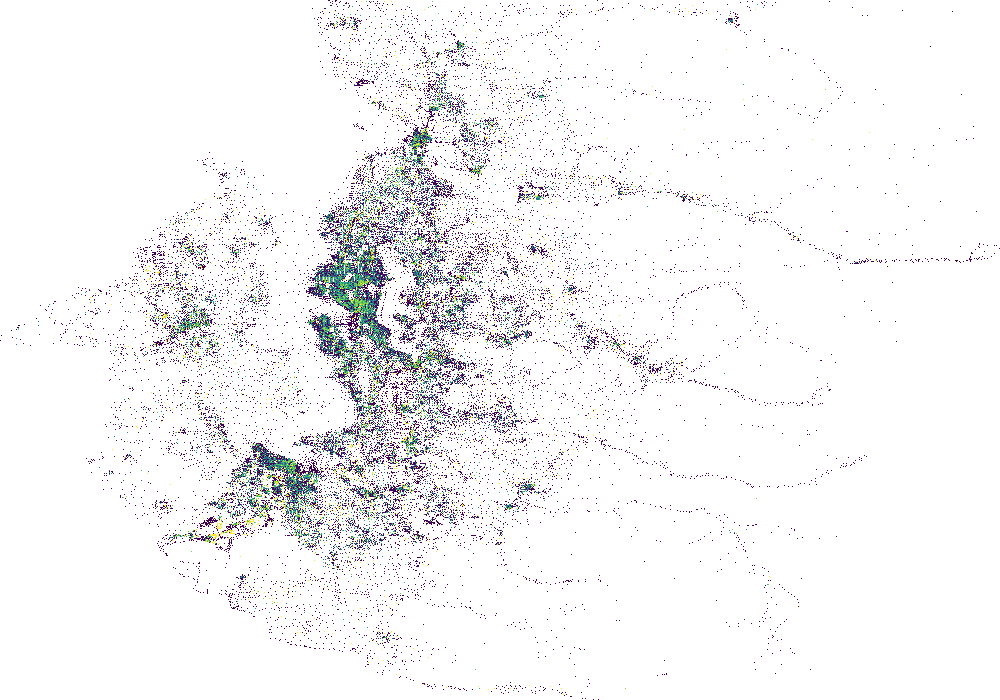

In [ ]:
visualize_variable('block_groups_prop_workers_aggr_occ_1')

In [15]:
# Set explanatory variables
expl_vars = [
    # travel skim variables
    'st_ln_zones_total_jobs_15_minutes_am_single_vehicle_to_work_travel_time',
    'st_ln_zones_total_households_15_minutes_am_single_vehicle_to_work_travel_time',
    'st_ln_zones_total_jobs_30_minutes_am_single_vehicle_to_work_travel_time',
    'st_ln_zones_total_households_30_minutes_am_single_vehicle_to_work_travel_time',
    'st_ln_zones_total_jobs_45_minutes_am_single_vehicle_to_work_travel_time',
    'st_ln_zones_total_households_45_minutes_am_single_vehicle_to_work_travel_time',

    # hh accessibility variables
    'st_is_transit_stop_sum_800_flat',
    'st_is_transit_stop_sum_1600_flat',
    'st_is_transit_stop_sum_3200_flat',
    'st_is_urban_center_sum_800_flat',
    'st_is_urban_center_sum_1600_flat',
    'st_is_urban_center_sum_3200_flat',
    'st_sum_income_ave_800_flat', 
    'st_sum_income_ave_1600_flat', 
    'st_sum_income_ave_3200_flat', 
    'st_ln_res_value_ave_800_flat',
    'st_ln_res_value_ave_1600_flat',
    'st_ln_res_value_ave_3200_flat',
    'st_ln_res_rent_ave_800_flat',
    'st_ln_res_rent_ave_1600_flat',
    'st_ln_res_rent_ave_3200_flat',
    'st_prop_aggr_sector_id_1_ave_800_flat',
    'st_prop_aggr_sector_id_1_ave_1600_flat',
    'st_prop_aggr_sector_id_1_ave_3200_flat',
    'st_prop_aggr_sector_id_2_ave_800_flat',
    'st_prop_aggr_sector_id_2_ave_1600_flat',
    'st_prop_aggr_sector_id_2_ave_3200_flat',
    'st_prop_aggr_sector_id_3_ave_800_flat',
    'st_prop_aggr_sector_id_3_ave_1600_flat',
    'st_prop_aggr_sector_id_3_ave_3200_flat',
    'st_prop_aggr_sector_id_4_ave_800_flat',
    'st_prop_aggr_sector_id_4_ave_1600_flat',
    'st_prop_aggr_sector_id_4_ave_3200_flat',
    'st_prop_aggr_sector_id_5_ave_800_flat',
    'st_prop_aggr_sector_id_5_ave_1600_flat',
    'st_prop_aggr_sector_id_5_ave_3200_flat',

    # housing unit variables
    'st_sum_sf_ave_800_flat',
    'st_sum_sf_ave_1600_flat',
    'st_sum_sf_ave_3200_flat',
    'st_sum_middle_ave_800_flat',
    'st_sum_middle_ave_1600_flat',
    'st_sum_middle_ave_3200_flat',
    'st_sum_mf_ave_800_flat',
    'st_sum_mf_ave_1600_flat',
    'st_sum_mf_ave_3200_flat',
    'st_sum_sf_built_prev_10_years_ave_800_flat',
    'st_sum_sf_built_prev_10_years_ave_1600_flat',
    'st_sum_sf_built_prev_10_years_ave_3200_flat',
    'st_sum_middle_built_prev_10_years_ave_800_flat',
    'st_sum_middle_built_prev_10_years_ave_1600_flat',
    'st_sum_middle_built_prev_10_years_ave_3200_flat',
    'st_sum_mf_built_prev_10_years_ave_800_flat',
    'st_sum_mf_built_prev_10_years_ave_1600_flat',
    'st_sum_mf_built_prev_10_years_ave_3200_flat',
    'st_mean_year_built',

    # block group variables
    'st_block_groups_prop_year_built_2022', 
    'st_block_groups_prop_children_0',
    'st_ln_block_groups_density_housing_units',
    'st_ln_block_groups_density_jobs',
    'st_block_groups_prop_cars_0',
    'st_prop_worker_aggr_sector_1',
    'st_prop_worker_aggr_sector_2',
    'st_prop_worker_aggr_sector_3',
    'st_prop_worker_aggr_sector_4',
    'st_prop_worker_aggr_sector_5',
]

In [16]:
import numpy as np
from urbansim.models import util
from urbansim_templates.models import LargeMultinomialLogitStep

SEED = 42

def fit_hlcm(expl_vars, chooser_filters, out_chooser_filters,
             chooser_sample_size=2000, alt_sample_size=50):
    """One seeded fit; returns the choicemodels log_likelihood dict."""
    np.random.seed(SEED)          # MergedChoiceTable + DataFrame.sample both use the global RNG
    m = LargeMultinomialLogitStep()
    m.choosers = ['households']
    m.chooser_sample_size = chooser_sample_size
    m.chooser_filters = chooser_filters
    m.alternatives = ['blocks']
    m.choice_column = 'maz_id'
    m.constrained_choices = True
    m.alt_sample_size = alt_sample_size
    m.out_chooser_filters = out_chooser_filters
    m.alt_capacity = 'vacant_housing_units'
    m.out_alt_filters = 'vacant_housing_units > 0'
    m.model_expression = util.str_model_expression(list(expl_vars), add_constant=False)
    m.fit()
    return m

def coeffs(m):
    return dict(zip(util.columns_in_formula(m.model_expression), m.fitted_parameters))

def stepwise(candidates, chooser_filters, out_chooser_filters,
             max_vars=12, min_improvement=6.0, expected_sign=None, log=None):
    """Forward selection on BIC with a floating (drop) step."""
    selected, best_model = [], None
    best_bic = None
    while len(selected) < max_vars:
        trials = []
        for c in candidates:
            if c in selected:
                continue
            m = fit_hlcm(selected + [c], chooser_filters, out_chooser_filters)
            ll = m.model.results['log_likelihood']
            if expected_sign and np.sign(coeffs(m)[c]) != expected_sign.get(c, np.sign(coeffs(m)[c])):
                continue  # sign violation -> ineligible
            trials.append((ll['bic'], c, m, ll))
        if not trials:
            break
        bic, c, m, ll = min(trials, key=lambda t: t[0])
        if best_bic is not None and (best_bic - bic) < min_improvement:
            break
        selected.append(c); best_model, best_bic = m, bic
        if log is not None:
            log.append({'added': c, 'bic': bic, 'aic': ll['aic'],
                        'rho_bar_squared': ll['rho_bar_squared'],
                        'n_vars': ll['df_model']})
        # floating step: try dropping each selected var once
        for d in list(selected):
            trial = [v for v in selected if v != d]
            if not trial:
                continue
            m2 = fit_hlcm(trial, chooser_filters, out_chooser_filters)
            bic2 = m2.model.results['log_likelihood']['bic']
            if best_bic - bic2 > min_improvement:
                selected, best_model, best_bic = trial, m2, bic2
    return selected, best_model, best_bic

In [36]:
selected4, best_model4, best_bic4 = stepwise(expl_vars, '(recent_mover == 1) & (income_quartile == 4)','(maz_id == "-1") & (income_quartile == 4)')

                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,999
Method:       Maximum Likelihood   Df Model:                      1
Date:                 2026-09-29   Pseudo R-squ.:             0.032
Time:                      13:34   Pseudo R-bar-squ.:         0.032
AIC:                  15,145.277   Log-Likelihood:       -7,571.639
BIC:                  15,150.878   LL-Null:              -7,824.046
                                                                             coef   std err         z     P>|z|   Conf. Int.
----------------------------------------------------------------------------------------------------------------------------
st_ln_zones_total_jobs_15_minutes_am_single_vehicle_to_work_travel_time    0.7770     0.030    26.145     0.000             
                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:   

                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,999
Method:       Maximum Likelihood   Df Model:                      1
Date:                 2026-09-29   Pseudo R-squ.:             0.017
Time:                      13:34   Pseudo R-bar-squ.:         0.017
AIC:                  15,383.253   Log-Likelihood:       -7,690.627
BIC:                  15,388.854   LL-Null:              -7,824.046
                                     coef   std err         z     P>|z|   Conf. Int.
------------------------------------------------------------------------------------
st_is_transit_stop_sum_800_flat    0.2756     0.015    18.974     0.000             
                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,9

                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,999
Method:       Maximum Likelihood   Df Model:                      1
Date:                 2026-09-29   Pseudo R-squ.:             0.001
Time:                      13:34   Pseudo R-bar-squ.:         0.000
AIC:                  15,641.821   Log-Likelihood:       -7,819.910
BIC:                  15,647.422   LL-Null:              -7,824.046
                                           coef   std err         z     P>|z|   Conf. Int.
------------------------------------------------------------------------------------------
st_prop_aggr_sector_id_1_ave_800_flat    0.0608     0.020     2.997     0.003             
                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals

                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,997
Method:       Maximum Likelihood   Df Model:                      3
Date:                 2026-09-29   Pseudo R-squ.:             0.203
Time:                      13:34   Pseudo R-bar-squ.:         0.203
AIC:                  12,472.576   Log-Likelihood:       -6,233.288
BIC:                  12,489.378   LL-Null:              -7,824.046
                                      coef   std err         z     P>|z|   Conf. Int.
-------------------------------------------------------------------------------------
st_sum_income_ave_800_flat          4.8972     0.045   109.755     0.000             
st_prop_worker_aggr_sector_4        0.2317     0.011    21.983     0.000             
st_is_transit_stop_sum_1600_flat    0.1417     0.020     6.997     0.000             
                  CHOICEMO

                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,997
Method:       Maximum Likelihood   Df Model:                      3
Date:                 2026-09-29   Pseudo R-squ.:             0.201
Time:                      13:34   Pseudo R-bar-squ.:         0.200
AIC:                  12,513.631   Log-Likelihood:       -6,253.815
BIC:                  12,530.433   LL-Null:              -7,824.046
                                  coef   std err         z     P>|z|   Conf. Int.
---------------------------------------------------------------------------------
st_sum_income_ave_800_flat      4.8403     0.051    95.251     0.000             
st_prop_worker_aggr_sector_4    0.2469     0.010    24.787     0.000             
st_ln_res_rent_ave_800_flat     0.0732     0.027     2.728     0.006             
                  CHOICEMODELS ESTIMATION RESU

                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,997
Method:       Maximum Likelihood   Df Model:                      3
Date:                 2026-09-29   Pseudo R-squ.:             0.202
Time:                      13:34   Pseudo R-bar-squ.:         0.202
AIC:                  12,490.666   Log-Likelihood:       -6,242.333
BIC:                  12,507.468   LL-Null:              -7,824.046
                                  coef   std err         z     P>|z|   Conf. Int.
---------------------------------------------------------------------------------
st_sum_income_ave_800_flat      4.8290     0.049    98.568     0.000             
st_prop_worker_aggr_sector_4    0.2345     0.011    22.214     0.000             
st_sum_mf_ave_3200_flat         0.1351     0.024     5.538     0.000             
                  CHOICEMODELS ESTIMATION RESU

                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,996
Method:       Maximum Likelihood   Df Model:                      4
Date:                 2026-09-29   Pseudo R-squ.:             0.209
Time:                      13:34   Pseudo R-bar-squ.:         0.209
AIC:                  12,383.388   Log-Likelihood:       -6,187.694
BIC:                  12,405.792   LL-Null:              -7,824.046
                                              coef   std err         z     P>|z|   Conf. Int.
---------------------------------------------------------------------------------------------
st_sum_income_ave_800_flat                  4.7705     0.050    95.525     0.000             
st_prop_worker_aggr_sector_4                0.2027     0.012    17.435     0.000             
st_ln_block_groups_density_housing_units    0.2236     0.021    10.841     0.000

                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,996
Method:       Maximum Likelihood   Df Model:                      4
Date:                 2026-09-29   Pseudo R-squ.:             0.213
Time:                      13:34   Pseudo R-bar-squ.:         0.212
AIC:                  12,328.138   Log-Likelihood:       -6,160.069
BIC:                  12,350.542   LL-Null:              -7,824.046
                                              coef   std err         z     P>|z|   Conf. Int.
---------------------------------------------------------------------------------------------
st_sum_income_ave_800_flat                  4.8355     0.051    94.752     0.000             
st_prop_worker_aggr_sector_4                0.2038     0.012    16.979     0.000             
st_ln_block_groups_density_housing_units    0.2387     0.019    12.434     0.000

       -3.36543820e-07]), 'task': 'ABNORMAL: ', 'funcalls': 53, 'nit': 17, 'warnflag': 2})


                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,995
Method:       Maximum Likelihood   Df Model:                      5
Date:                 2026-09-29   Pseudo R-squ.:             0.218
Time:                      13:34   Pseudo R-bar-squ.:         0.217
AIC:                  12,253.449   Log-Likelihood:       -6,121.725
BIC:                  12,281.454   LL-Null:              -7,824.046
                                              coef   std err         z     P>|z|   Conf. Int.
---------------------------------------------------------------------------------------------
st_sum_income_ave_800_flat                  4.1133     0.065    63.693     0.000             
st_prop_worker_aggr_sector_4                0.1850     0.013    13.853     0.000             
st_ln_block_groups_density_housing_units    0.2445     0.020    12.528     0.000

       -2.10344880e-05]), 'task': 'ABNORMAL: ', 'funcalls': 64, 'nit': 15, 'warnflag': 2})


                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,995
Method:       Maximum Likelihood   Df Model:                      5
Date:                 2026-09-29   Pseudo R-squ.:             0.215
Time:                      13:34   Pseudo R-bar-squ.:         0.214
AIC:                  12,297.495   Log-Likelihood:       -6,143.748
BIC:                  12,325.500   LL-Null:              -7,824.046
                                              coef   std err         z     P>|z|   Conf. Int.
---------------------------------------------------------------------------------------------
st_sum_income_ave_800_flat                  4.2655     0.110    38.943     0.000             
st_prop_worker_aggr_sector_4                0.2021     0.013    15.684     0.000             
st_ln_block_groups_density_housing_units    0.2676     0.031     8.607     0.000

       -2.18550080e-03]), np.float64(6144.039156921336), {'grad': array([ 2.40011423e-06, -1.38794866e-05,  3.55364152e-06, -2.47233964e-06,
        6.82842408e-06]), 'task': 'ABNORMAL: ', 'funcalls': 56, 'nit': 16, 'warnflag': 2})


                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,995
Method:       Maximum Likelihood   Df Model:                      5
Date:                 2026-09-29   Pseudo R-squ.:             0.215
Time:                      13:34   Pseudo R-bar-squ.:         0.214
AIC:                  12,297.337   Log-Likelihood:       -6,143.668
BIC:                  12,325.341   LL-Null:              -7,824.046
                                                    coef   std err         z     P>|z|   Conf. Int.
---------------------------------------------------------------------------------------------------
st_sum_income_ave_800_flat                        4.3081     0.059    72.477     0.000             
st_prop_worker_aggr_sector_4                      0.2012     0.013    16.081     0.000             
st_ln_block_groups_density_housing_units          0.2489

       0.0122072 ]), np.float64(6108.138573198685), {'grad': array([ 8.85805065e-08,  9.45904046e-06, -5.75171241e-06, -1.98014102e-06,
       -6.44412728e-06, -2.19123261e-05]), 'task': 'ABNORMAL: ', 'funcalls': 57, 'nit': 17, 'warnflag': 2})


                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,994
Method:       Maximum Likelihood   Df Model:                      6
Date:                 2026-09-29   Pseudo R-squ.:             0.220
Time:                      13:34   Pseudo R-bar-squ.:         0.219
AIC:                  12,218.491   Log-Likelihood:       -6,103.245
BIC:                  12,252.096   LL-Null:              -7,824.046
                                                                                   coef   std err         z     P>|z|   Conf. Int.
----------------------------------------------------------------------------------------------------------------------------------
st_sum_income_ave_800_flat                                                       4.3822     0.063    69.769     0.000             
st_prop_worker_aggr_sector_4                                   

       -0.09984437]), np.float64(6102.09935746078), {'grad': array([ 7.32739251e-06,  3.95450928e-05,  5.42404060e-05, -1.27312646e-05,
        1.72509522e-04, -1.96062956e-05]), 'task': 'ABNORMAL: ', 'funcalls': 57, 'nit': 16, 'warnflag': 2})


                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,994
Method:       Maximum Likelihood   Df Model:                      6
Date:                 2026-09-29   Pseudo R-squ.:             0.220
Time:                      13:34   Pseudo R-bar-squ.:         0.219
AIC:                  12,222.246   Log-Likelihood:       -6,105.123
BIC:                  12,255.851   LL-Null:              -7,824.046
                                              coef   std err         z     P>|z|   Conf. Int.
---------------------------------------------------------------------------------------------
st_sum_income_ave_800_flat                  4.4314     0.058    76.188     0.000             
st_prop_worker_aggr_sector_4                0.1990     0.013    15.092     0.000             
st_ln_block_groups_density_housing_units    0.2366     0.021    11.296     0.000

       -0.00466734]), np.float64(6108.284566986771), {'grad': array([ 2.18227941e-06,  9.59954518e-06,  3.78697095e-07, -1.02062347e-05,
        1.31068777e-05, -3.56126476e-06]), 'task': 'ABNORMAL: ', 'funcalls': 58, 'nit': 17, 'warnflag': 2})


                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,994
Method:       Maximum Likelihood   Df Model:                      6
Date:                 2026-09-29   Pseudo R-squ.:             0.219
Time:                      13:34   Pseudo R-bar-squ.:         0.219
AIC:                  12,228.589   Log-Likelihood:       -6,108.295
BIC:                  12,262.195   LL-Null:              -7,824.046
                                              coef   std err         z     P>|z|   Conf. Int.
---------------------------------------------------------------------------------------------
st_sum_income_ave_800_flat                  4.4011     0.059    74.535     0.000             
st_prop_worker_aggr_sector_4                0.2012     0.013    15.376     0.000             
st_ln_block_groups_density_housing_units    0.2553     0.019    13.112     0.000

       -0.00605346]), np.float64(6108.27711542231), {'grad': array([ 3.87233694e-06, -2.93199782e-05,  2.75746065e-05, -3.90405473e-06,
        4.59536196e-05,  4.26641317e-05]), 'task': 'ABNORMAL: ', 'funcalls': 55, 'nit': 17, 'warnflag': 2})


                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,994
Method:       Maximum Likelihood   Df Model:                      6
Date:                 2026-09-29   Pseudo R-squ.:             0.219
Time:                      13:34   Pseudo R-bar-squ.:         0.219
AIC:                  12,228.554   Log-Likelihood:       -6,108.277
BIC:                  12,262.160   LL-Null:              -7,824.046
                                              coef   std err         z     P>|z|   Conf. Int.
---------------------------------------------------------------------------------------------
st_sum_income_ave_800_flat                  4.4066     0.057    76.650     0.000             
st_prop_worker_aggr_sector_4                0.2012     0.013    15.362     0.000             
st_ln_block_groups_density_housing_units    0.2583     0.023    11.438     0.000

       -0.12059472]), np.float64(6103.656414181597), {'grad': array([-1.52949820e-07, -6.46261283e-06,  1.16144686e-05,  3.49299632e-06,
       -4.90697989e-06, -4.53590870e-06]), 'task': 'ABNORMAL: ', 'funcalls': 59, 'nit': 18, 'warnflag': 2})


                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,994
Method:       Maximum Likelihood   Df Model:                      6
Date:                 2026-09-29   Pseudo R-squ.:             0.220
Time:                      13:34   Pseudo R-bar-squ.:         0.219
AIC:                  12,219.313   Log-Likelihood:       -6,103.656
BIC:                  12,252.918   LL-Null:              -7,824.046
                                              coef   std err         z     P>|z|   Conf. Int.
---------------------------------------------------------------------------------------------
st_sum_income_ave_800_flat                  4.5069     0.072    62.697     0.000             
st_prop_worker_aggr_sector_4                0.1946     0.014    14.304     0.000             
st_ln_block_groups_density_housing_units    0.2047     0.025     8.137     0.000

       0.18151369]), np.float64(6079.536812005175), {'grad': array([ 1.42160566e-05,  7.32991303e-05, -3.12264028e-06,  1.62925456e-05,
        3.03041477e-05,  1.24509413e-05]), 'task': 'ABNORMAL: ', 'funcalls': 53, 'nit': 16, 'warnflag': 2})


                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,994
Method:       Maximum Likelihood   Df Model:                      6
Date:                 2026-09-29   Pseudo R-squ.:             0.220
Time:                      13:34   Pseudo R-bar-squ.:         0.219
AIC:                  12,221.796   Log-Likelihood:       -6,104.898
BIC:                  12,255.402   LL-Null:              -7,824.046
                                              coef   std err         z     P>|z|   Conf. Int.
---------------------------------------------------------------------------------------------
st_sum_income_ave_800_flat                  4.4202     0.058    76.335     0.000             
st_prop_worker_aggr_sector_4                0.2034     0.013    15.528     0.000             
st_ln_block_groups_density_housing_units    0.2620     0.020    13.193     0.000

        0.2460373 , -0.08674081]), np.float64(6075.295837778335), {'grad': array([-1.56268775e-06, -1.32198879e-05,  1.75458160e-06,  6.17114137e-06,
       -3.26880863e-06,  8.79703050e-06,  9.97145094e-07]), 'task': 'ABNORMAL: ', 'funcalls': 60, 'nit': 23, 'warnflag': 2})


                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,993
Method:       Maximum Likelihood   Df Model:                      7
Date:                 2026-09-29   Pseudo R-squ.:             0.224
Time:                      13:34   Pseudo R-bar-squ.:         0.223
AIC:                  12,164.592   Log-Likelihood:       -6,075.296
BIC:                  12,203.798   LL-Null:              -7,824.046
                                                                                   coef   std err         z     P>|z|   Conf. Int.
----------------------------------------------------------------------------------------------------------------------------------
st_sum_income_ave_800_flat                                                       4.1416     0.072    57.243     0.000             
st_prop_worker_aggr_sector_4                                   

        0.24242216, -0.01005127]), np.float64(6076.132756383049), {'grad': array([ 1.63577963e-05,  2.28977041e-04, -9.38026332e-05, -1.06013744e-04,
        8.79518970e-05,  1.28384118e-04,  1.18863648e-04]), 'task': 'ABNORMAL: ', 'funcalls': 57, 'nit': 17, 'warnflag': 2})


                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,993
Method:       Maximum Likelihood   Df Model:                      7
Date:                 2026-09-29   Pseudo R-squ.:             0.224
Time:                      13:34   Pseudo R-bar-squ.:         0.223
AIC:                  12,164.542   Log-Likelihood:       -6,075.271
BIC:                  12,203.748   LL-Null:              -7,824.046
                                              coef   std err         z     P>|z|   Conf. Int.
---------------------------------------------------------------------------------------------
st_sum_income_ave_800_flat                  4.1602     0.071    58.777     0.000             
st_prop_worker_aggr_sector_4                0.1801     0.015    12.401     0.000             
st_ln_block_groups_density_housing_units    0.2445     0.022    11.185     0.000

       0.24378927, 0.02076696]), np.float64(6076.122141181344), {'grad': array([-1.02053196e-05,  4.48891288e-06, -4.52412148e-05, -3.86910549e-05,
        5.86825183e-05,  1.74095769e-05,  2.17299078e-05]), 'task': 'ABNORMAL: ', 'funcalls': 55, 'nit': 18, 'warnflag': 2})


                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,993
Method:       Maximum Likelihood   Df Model:                      7
Date:                 2026-09-29   Pseudo R-squ.:             0.223
Time:                      13:35   Pseudo R-bar-squ.:         0.222
AIC:                  12,166.444   Log-Likelihood:       -6,076.222
BIC:                  12,205.651   LL-Null:              -7,824.046
                                              coef   std err         z     P>|z|   Conf. Int.
---------------------------------------------------------------------------------------------
st_sum_income_ave_800_flat                  4.1401     0.071    58.700     0.000             
st_prop_worker_aggr_sector_4                0.1811     0.014    12.522     0.000             
st_ln_block_groups_density_housing_units    0.2585     0.022    11.886     0.000

       0.24682048, 0.03196196]), np.float64(6075.484794620223), {'grad': array([ 4.04830042e-06, -1.19858839e-06, -5.16536134e-05, -9.66884867e-06,
       -1.22811016e-07,  8.97793545e-06,  3.76356164e-05]), 'task': 'ABNORMAL: ', 'funcalls': 62, 'nit': 20, 'warnflag': 2})


                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,993
Method:       Maximum Likelihood   Df Model:                      7
Date:                 2026-09-29   Pseudo R-squ.:             0.223
Time:                      13:35   Pseudo R-bar-squ.:         0.223
AIC:                  12,164.970   Log-Likelihood:       -6,075.485
BIC:                  12,204.176   LL-Null:              -7,824.046
                                                coef   std err         z     P>|z|   Conf. Int.
-----------------------------------------------------------------------------------------------
st_sum_income_ave_800_flat                    4.0502     0.087    46.564     0.000             
st_prop_worker_aggr_sector_4                  0.1823     0.014    12.696     0.000             
st_ln_block_groups_density_housing_units      0.2746     0.024    11.298

        0.23826141, -0.07842922]), np.float64(6072.264619197995), {'grad': array([ 7.78208884e-07, -8.76295659e-06, -1.02414553e-05,  1.70000412e-05,
        3.75634443e-06,  1.92433494e-06, -1.94108419e-06]), 'task': 'ABNORMAL: ', 'funcalls': 61, 'nit': 20, 'warnflag': 2})


                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,993
Method:       Maximum Likelihood   Df Model:                      7
Date:                 2026-09-29   Pseudo R-squ.:             0.223
Time:                      13:35   Pseudo R-bar-squ.:         0.222
AIC:                  12,166.395   Log-Likelihood:       -6,076.197
BIC:                  12,205.601   LL-Null:              -7,824.046
                                                coef   std err         z     P>|z|   Conf. Int.
-----------------------------------------------------------------------------------------------
st_sum_income_ave_800_flat                    4.1266     0.072    57.481     0.000             
st_prop_worker_aggr_sector_4                  0.1810     0.014    12.514     0.000             
st_ln_block_groups_density_housing_units      0.2532     0.028     9.005

       0.27306436, 0.20075566]), np.float64(6040.0929839899145), {'grad': array([ 3.68311339e-06, -2.58051000e-05,  2.37748026e-08,  2.62632407e-05,
       -1.41723487e-05, -8.31150209e-06,  2.50681260e-05]), 'task': 'ABNORMAL: ', 'funcalls': 54, 'nit': 19, 'warnflag': 2})


                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,993
Method:       Maximum Likelihood   Df Model:                      7
Date:                 2026-09-29   Pseudo R-squ.:             0.228
Time:                      13:35   Pseudo R-bar-squ.:         0.227
AIC:                  12,094.186   Log-Likelihood:       -6,040.093
BIC:                  12,133.392   LL-Null:              -7,824.046
                                              coef   std err         z     P>|z|   Conf. Int.
---------------------------------------------------------------------------------------------
st_sum_income_ave_800_flat                  4.1584     0.072    57.759     0.000             
st_prop_worker_aggr_sector_4                0.1849     0.015    12.549     0.000             
st_ln_block_groups_density_housing_units    0.2688     0.020    13.660     0.000

       0.17919622]), np.float64(6615.859962256693), {'grad': array([-4.05108701e-05,  1.65505079e-05,  3.92500415e-05, -9.66680058e-05,
        1.14549293e-05, -5.42313676e-05]), 'task': 'ABNORMAL: ', 'funcalls': 47, 'nit': 10, 'warnflag': 2})


                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,994
Method:       Maximum Likelihood   Df Model:                      6
Date:                 2026-09-29   Pseudo R-squ.:             0.154
Time:                      13:35   Pseudo R-bar-squ.:         0.154
AIC:                  13,243.720   Log-Likelihood:       -6,615.860
BIC:                  13,277.325   LL-Null:              -7,824.046
                                              coef   std err         z     P>|z|   Conf. Int.
---------------------------------------------------------------------------------------------
st_prop_worker_aggr_sector_4                0.1924     0.013    14.766     0.000             
st_ln_block_groups_density_housing_units    0.4930     0.018    26.971     0.000             
st_mean_year_built                          0.4880     0.022    22.497     0.000

       0.18151369]), np.float64(6079.536812005175), {'grad': array([ 1.42160566e-05,  7.32991303e-05, -3.12264028e-06,  1.62925456e-05,
        3.03041477e-05,  1.24509413e-05]), 'task': 'ABNORMAL: ', 'funcalls': 53, 'nit': 16, 'warnflag': 2})


                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,994
Method:       Maximum Likelihood   Df Model:                      6
Date:                 2026-09-29   Pseudo R-squ.:             0.223
Time:                      13:35   Pseudo R-bar-squ.:         0.222
AIC:                  12,172.794   Log-Likelihood:       -6,080.397
BIC:                  12,206.399   LL-Null:              -7,824.046
                                              coef   std err         z     P>|z|   Conf. Int.
---------------------------------------------------------------------------------------------
st_sum_income_ave_800_flat                  4.1188     0.067    61.432     0.000             
st_prop_worker_aggr_sector_4                0.1855     0.014    13.454     0.000             
st_ln_block_groups_density_housing_units    0.2641     0.020    13.532     0.000

       0.27359734, 0.20083673, 0.00509999]), np.float64(6040.072153226321), {'grad': array([ 2.89967047e-05, -3.67348278e-05, -1.79531432e-05,  1.45271073e-05,
       -2.98661457e-05, -1.04244109e-05, -4.11560733e-05, -2.30759800e-05]), 'task': 'ABNORMAL: ', 'funcalls': 58, 'nit': 19, 'warnflag': 2})


                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,992
Method:       Maximum Likelihood   Df Model:                      8
Date:                 2026-09-29   Pseudo R-squ.:             0.228
Time:                      13:35   Pseudo R-bar-squ.:         0.227
AIC:                  12,096.144   Log-Likelihood:       -6,040.072
BIC:                  12,140.952   LL-Null:              -7,824.046
                                              coef   std err         z     P>|z|   Conf. Int.
---------------------------------------------------------------------------------------------
st_sum_income_ave_800_flat                  4.1555     0.073    56.770     0.000             
st_prop_worker_aggr_sector_4                0.1849     0.015    12.550     0.000             
st_ln_block_groups_density_housing_units    0.2673     0.021    12.837     0.000

        2.27162418e-01,  2.73051685e-01,  2.00753791e-01, -5.12744405e-05]), np.float64(6040.092982590349), {'grad': array([-6.10495809e-06, -9.78457694e-05,  7.93746768e-05,  1.28306382e-04,
       -4.25902623e-05, -6.04498288e-05,  8.61096494e-05,  8.74101636e-05]), 'task': 'ABNORMAL: ', 'funcalls': 63, 'nit': 23, 'warnflag': 2})


                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,992
Method:       Maximum Likelihood   Df Model:                      8
Date:                 2026-09-29   Pseudo R-squ.:             0.228
Time:                      13:35   Pseudo R-bar-squ.:         0.227
AIC:                  12,096.186   Log-Likelihood:       -6,040.093
BIC:                  12,140.993   LL-Null:              -7,824.046
                                              coef   std err         z     P>|z|   Conf. Int.
---------------------------------------------------------------------------------------------
st_sum_income_ave_800_flat                  4.1585     0.079    52.424     0.000             
st_prop_worker_aggr_sector_4                0.1849     0.015    12.535     0.000             
st_ln_block_groups_density_housing_units    0.2688     0.028     9.714     0.000

       0.27453659, 0.20302621, 0.05110828]), np.float64(6038.04040881281), {'grad': array([-2.56825839e-07,  1.87957173e-05, -6.78042029e-06,  4.54905440e-05,
       -3.84501081e-05, -3.24478776e-05,  2.97120855e-05, -3.76357983e-06]), 'task': 'ABNORMAL: ', 'funcalls': 58, 'nit': 21, 'warnflag': 2})


                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,992
Method:       Maximum Likelihood   Df Model:                      8
Date:                 2026-09-29   Pseudo R-squ.:             0.228
Time:                      13:35   Pseudo R-bar-squ.:         0.227
AIC:                  12,092.081   Log-Likelihood:       -6,038.040
BIC:                  12,136.888   LL-Null:              -7,824.046
                                              coef   std err         z     P>|z|   Conf. Int.
---------------------------------------------------------------------------------------------
st_sum_income_ave_800_flat                  4.1506     0.072    57.566     0.000             
st_prop_worker_aggr_sector_4                0.1824     0.015    12.158     0.000             
st_ln_block_groups_density_housing_units    0.2276     0.027     8.319     0.000

       0.27306436, 0.20075566]), np.float64(6040.0929839899145), {'grad': array([ 3.68311339e-06, -2.58051000e-05,  2.37748026e-08,  2.62632407e-05,
       -1.41723487e-05, -8.31150209e-06,  2.50681260e-05]), 'task': 'ABNORMAL: ', 'funcalls': 54, 'nit': 19, 'warnflag': 2})


                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,993
Method:       Maximum Likelihood   Df Model:                      7
Date:                 2026-09-29   Pseudo R-squ.:             0.228
Time:                      13:35   Pseudo R-bar-squ.:         0.227
AIC:                  12,094.186   Log-Likelihood:       -6,040.093
BIC:                  12,133.392   LL-Null:              -7,824.046
                                              coef   std err         z     P>|z|   Conf. Int.
---------------------------------------------------------------------------------------------
st_sum_income_ave_800_flat                  4.1584     0.072    57.759     0.000             
st_prop_worker_aggr_sector_4                0.1849     0.015    12.549     0.000             
st_ln_block_groups_density_housing_units    0.2688     0.020    13.660     0.000

       0.19668227, 0.20032961, 0.15065669, 0.08563205]), np.float64(6014.752756551273), {'grad': array([1.88772964e-05, 3.29928773e-05, 6.90189864e-05, 1.25425150e-05,
       1.70549420e-05, 1.36451432e-05, 4.60280437e-05, 1.43235272e-05,
       1.55453730e-05]), 'task': 'ABNORMAL: ', 'funcalls': 58, 'nit': 24, 'warnflag': 2})


                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,991
Method:       Maximum Likelihood   Df Model:                      9
Date:                 2026-09-29   Pseudo R-squ.:             0.231
Time:                      13:35   Pseudo R-bar-squ.:         0.230
AIC:                  12,047.506   Log-Likelihood:       -6,014.753
BIC:                  12,097.914   LL-Null:              -7,824.046
                                              coef   std err         z     P>|z|   Conf. Int.
---------------------------------------------------------------------------------------------
st_sum_income_ave_800_flat                  4.1182     0.075    54.621     0.000             
st_prop_worker_aggr_sector_4                0.1777     0.016    10.871     0.000             
st_ln_block_groups_density_housing_units    0.2213     0.023     9.741     0.000

        0.33866467,  0.19397206,  0.15410231, -1.23316694, -0.02966376]), np.float64(5996.236492554312), {'grad': array([ 8.36923224e-08, -3.45773202e-05, -4.96714411e-05, -3.47325854e-05,
       -1.38159882e-05, -1.40583207e-05,  2.67225862e-05, -2.88393015e-05,
        3.91244439e-06,  2.63877328e-05]), 'task': 'ABNORMAL: ', 'funcalls': 78, 'nit': 35, 'warnflag': 2})


                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,990
Method:       Maximum Likelihood   Df Model:                     10
Date:                 2026-09-29   Pseudo R-squ.:             0.234
Time:                      13:35   Pseudo R-bar-squ.:         0.232
AIC:                  12,012.473   Log-Likelihood:       -5,996.236
BIC:                  12,068.482   LL-Null:              -7,824.046
                                                                             coef   std err         z     P>|z|   Conf. Int.
----------------------------------------------------------------------------------------------------------------------------
st_sum_income_ave_800_flat                                                 5.0108     0.167    30.069     0.000             
st_prop_worker_aggr_sector_4                                               0.1801

        0.3475353 ,  0.19471127,  0.15465339, -1.2322733 , -0.05719877]), np.float64(5995.981420977626), {'grad': array([ 1.95004479e-06,  3.29274906e-06,  1.09100118e-05,  1.13263771e-05,
        1.54387217e-06, -2.40464966e-06,  1.00643806e-06,  2.14035430e-05,
        2.66149928e-06, -1.66854924e-06]), 'task': 'ABNORMAL: ', 'funcalls': 67, 'nit': 33, 'warnflag': 2})


                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,990
Method:       Maximum Likelihood   Df Model:                     10
Date:                 2026-09-29   Pseudo R-squ.:             0.234
Time:                      13:35   Pseudo R-bar-squ.:         0.232
AIC:                  12,011.963   Log-Likelihood:       -5,995.981
BIC:                  12,067.972   LL-Null:              -7,824.046
                                                                             coef   std err         z     P>|z|   Conf. Int.
----------------------------------------------------------------------------------------------------------------------------
st_sum_income_ave_800_flat                                                 5.0001     0.167    29.993     0.000             
st_prop_worker_aggr_sector_4                                               0.1800

        0.33994962,  0.19462813,  0.15343389, -1.27563098,  0.03038088]), np.float64(5995.870077283776), {'grad': array([-5.02438747e-06, -3.59851554e-06, -9.14582210e-06,  4.72119660e-06,
       -1.14585026e-05, -6.41646298e-06,  1.69039667e-05, -9.30621994e-06,
       -9.49886444e-07,  1.03602266e-05]), 'task': 'ABNORMAL: ', 'funcalls': 68, 'nit': 30, 'warnflag': 2})


                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,990
Method:       Maximum Likelihood   Df Model:                     10
Date:                 2026-09-29   Pseudo R-squ.:             0.234
Time:                      13:35   Pseudo R-bar-squ.:         0.232
AIC:                  12,011.740   Log-Likelihood:       -5,995.870
BIC:                  12,067.749   LL-Null:              -7,824.046
                                              coef   std err         z     P>|z|   Conf. Int.
---------------------------------------------------------------------------------------------
st_sum_income_ave_800_flat                  5.0194     0.167    30.102     0.000             
st_prop_worker_aggr_sector_4                0.1793     0.016    10.938     0.000             
st_ln_block_groups_density_housing_units    0.2457     0.024    10.181     0.000

        0.3365998 ,  0.19385866,  0.15431665, -1.2330238 ,  0.00938047]), np.float64(5996.279116167103), {'grad': array([ 2.09888819e-06,  6.91755587e-05,  3.85313065e-05,  3.89880012e-05,
       -2.49981392e-05,  1.19941971e-06,  2.30557657e-05,  2.84415566e-05,
        3.68869502e-06,  5.40175316e-06]), 'task': 'ABNORMAL: ', 'funcalls': 69, 'nit': 28, 'warnflag': 2})


                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,990
Method:       Maximum Likelihood   Df Model:                     10
Date:                 2026-09-29   Pseudo R-squ.:             0.234
Time:                      13:35   Pseudo R-bar-squ.:         0.232
AIC:                  12,012.558   Log-Likelihood:       -5,996.279
BIC:                  12,068.567   LL-Null:              -7,824.046
                                                    coef   std err         z     P>|z|   Conf. Int.
---------------------------------------------------------------------------------------------------
st_sum_income_ave_800_flat                        4.9843     0.175    28.470     0.000             
st_prop_worker_aggr_sector_4                      0.1801     0.016    10.977     0.000             
st_ln_block_groups_density_housing_units          0.2535

In [37]:
print(best_model4.summary_table)

                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,991
Method:       Maximum Likelihood   Df Model:                      9
Date:                 2026-09-29   Pseudo R-squ.:             0.234
Time:                      13:35   Pseudo R-bar-squ.:         0.232
AIC:                  12,010.796   Log-Likelihood:       -5,996.398
BIC:                  12,061.204   LL-Null:              -7,824.046
                                              coef   std err         z     P>|z|   Conf. Int.
---------------------------------------------------------------------------------------------
st_sum_income_ave_800_flat                  5.0172     0.167    30.112     0.000             
st_prop_worker_aggr_sector_4                0.1797     0.016    10.970     0.000             
st_ln_block_groups_density_housing_units    0.2546     0.022    11.348     0.000

In [38]:
selected3, best_model3, best_bic3 = stepwise(expl_vars, '(recent_mover == 1) & (income_quartile == 3)','(maz_id == "-1") & (income_quartile == 3)')

                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,999
Method:       Maximum Likelihood   Df Model:                      1
Date:                 2026-09-29   Pseudo R-squ.:             0.025
Time:                      13:35   Pseudo R-bar-squ.:         0.025
AIC:                  15,263.040   Log-Likelihood:       -7,630.520
BIC:                  15,268.641   LL-Null:              -7,824.046
                                                                             coef   std err         z     P>|z|   Conf. Int.
----------------------------------------------------------------------------------------------------------------------------
st_ln_zones_total_jobs_15_minutes_am_single_vehicle_to_work_travel_time    0.6490     0.030    21.853     0.000             
                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:   

                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,999
Method:       Maximum Likelihood   Df Model:                      1
Date:                 2026-09-29   Pseudo R-squ.:             0.014
Time:                      13:36   Pseudo R-bar-squ.:         0.014
AIC:                  15,427.657   Log-Likelihood:       -7,712.828
BIC:                  15,433.258   LL-Null:              -7,824.046
                                     coef   std err         z     P>|z|   Conf. Int.
------------------------------------------------------------------------------------
st_is_transit_stop_sum_800_flat    0.2554     0.015    17.141     0.000             
                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,9

                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,999
Method:       Maximum Likelihood   Df Model:                      1
Date:                 2026-09-29   Pseudo R-squ.:             0.098
Time:                      13:36   Pseudo R-bar-squ.:         0.098
AIC:                  14,109.219   Log-Likelihood:       -7,053.610
BIC:                  14,114.820   LL-Null:              -7,824.046
                                 coef   std err         z     P>|z|   Conf. Int.
--------------------------------------------------------------------------------
st_sum_income_ave_1600_flat    3.4330     0.047    72.708     0.000             
                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,999
Method:  

                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,998
Method:       Maximum Likelihood   Df Model:                      2
Date:                 2026-09-29   Pseudo R-squ.:             0.161
Time:                      13:36   Pseudo R-bar-squ.:         0.160
AIC:                  13,139.122   Log-Likelihood:       -6,567.561
BIC:                  13,150.324   LL-Null:              -7,824.046
                                                coef   std err         z     P>|z|   Conf. Int.
-----------------------------------------------------------------------------------------------
st_sum_income_ave_800_flat                    4.9722     0.048   104.275     0.000             
st_sum_sf_built_prev_10_years_ave_800_flat   -0.1095     0.019    -5.770     0.000             
                  CHOICEMODELS ESTIMATION RESULTS                  
Dep.

                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,998
Method:       Maximum Likelihood   Df Model:                      2
Date:                 2026-09-29   Pseudo R-squ.:             0.175
Time:                      13:36   Pseudo R-bar-squ.:         0.175
AIC:                  12,909.590   Log-Likelihood:       -6,452.795
BIC:                  12,920.792   LL-Null:              -7,824.046
                                                coef   std err         z     P>|z|   Conf. Int.
-----------------------------------------------------------------------------------------------
st_sum_income_ave_800_flat                    3.8054     0.055    69.634     0.000             
st_sum_mf_built_prev_10_years_ave_800_flat    0.2713     0.016    16.551     0.000             
                  CHOICEMODELS ESTIMATION RESULTS                  
Dep.

                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,997
Method:       Maximum Likelihood   Df Model:                      3
Date:                 2026-09-29   Pseudo R-squ.:             0.177
Time:                      13:36   Pseudo R-bar-squ.:         0.177
AIC:                  12,881.918   Log-Likelihood:       -6,437.959
BIC:                  12,898.720   LL-Null:              -7,824.046
                                                coef   std err         z     P>|z|   Conf. Int.
-----------------------------------------------------------------------------------------------
st_sum_income_ave_800_flat                    3.7329     0.058    64.887     0.000             
st_sum_mf_ave_800_flat                        0.2253     0.038     5.924     0.000             
st_sum_mf_built_prev_10_years_ave_800_flat    0.1192     0.030     3.921

                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,996
Method:       Maximum Likelihood   Df Model:                      4
Date:                 2026-09-29   Pseudo R-squ.:             0.186
Time:                      13:36   Pseudo R-bar-squ.:         0.185
AIC:                  12,748.719   Log-Likelihood:       -6,370.360
BIC:                  12,771.123   LL-Null:              -7,824.046
                                            coef   std err         z     P>|z|   Conf. Int.
-------------------------------------------------------------------------------------------
st_sum_income_ave_800_flat                3.3220     0.064    51.521     0.000             
st_sum_mf_ave_800_flat                    0.3844     0.022    17.440     0.000             
st_mean_year_built                        0.2878     0.025    11.285     0.000          

                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,996
Method:       Maximum Likelihood   Df Model:                      4
Date:                 2026-09-29   Pseudo R-squ.:             0.186
Time:                      13:36   Pseudo R-bar-squ.:         0.185
AIC:                  12,748.978   Log-Likelihood:       -6,370.489
BIC:                  12,771.381   LL-Null:              -7,824.046
                                            coef   std err         z     P>|z|   Conf. Int.
-------------------------------------------------------------------------------------------
st_sum_income_ave_800_flat                3.4436     0.062    55.877     0.000             
st_sum_mf_ave_800_flat                    0.3610     0.021    17.552     0.000             
st_mean_year_built                        0.2941     0.026    11.489     0.000          

                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,996
Method:       Maximum Likelihood   Df Model:                      4
Date:                 2026-09-29   Pseudo R-squ.:             0.186
Time:                      13:36   Pseudo R-bar-squ.:         0.186
AIC:                  12,742.869   Log-Likelihood:       -6,367.435
BIC:                  12,765.273   LL-Null:              -7,824.046
                                 coef   std err         z     P>|z|   Conf. Int.
--------------------------------------------------------------------------------
st_sum_income_ave_800_flat     3.3093     0.067    49.131     0.000             
st_sum_mf_ave_800_flat         0.3409     0.021    16.457     0.000             
st_mean_year_built             0.2865     0.025    11.251     0.000             
st_sum_middle_ave_1600_flat    0.1035     0.026    

                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,996
Method:       Maximum Likelihood   Df Model:                      4
Date:                 2026-09-29   Pseudo R-squ.:             0.185
Time:                      13:36   Pseudo R-bar-squ.:         0.185
AIC:                  12,756.011   Log-Likelihood:       -6,374.005
BIC:                  12,778.414   LL-Null:              -7,824.046
                                                 coef   std err         z     P>|z|   Conf. Int.
------------------------------------------------------------------------------------------------
st_sum_income_ave_800_flat                     3.4716     0.071    48.841     0.000             
st_sum_mf_ave_800_flat                         0.3427     0.024    14.252     0.000             
st_mean_year_built                             0.3058     0.028    1

       -3.50656552e-06]), 'task': 'ABNORMAL: ', 'funcalls': 50, 'nit': 15, 'warnflag': 2})


                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,995
Method:       Maximum Likelihood   Df Model:                      5
Date:                 2026-09-29   Pseudo R-squ.:             0.193
Time:                      13:36   Pseudo R-bar-squ.:         0.193
AIC:                  12,631.975   Log-Likelihood:       -6,310.987
BIC:                  12,659.979   LL-Null:              -7,824.046
                                  coef   std err         z     P>|z|   Conf. Int.
---------------------------------------------------------------------------------
st_sum_income_ave_800_flat      3.6109     0.068    53.442     0.000             
st_sum_mf_ave_800_flat          0.3744     0.021    17.982     0.000             
st_mean_year_built              0.3197     0.026    12.245     0.000             
st_prop_worker_aggr_sector_5    0.2095     0.0

       -6.30887932e-05]), 'task': 'ABNORMAL: ', 'funcalls': 50, 'nit': 14, 'warnflag': 2})


                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,995
Method:       Maximum Likelihood   Df Model:                      5
Date:                 2026-09-29   Pseudo R-squ.:             0.192
Time:                      13:36   Pseudo R-bar-squ.:         0.191
AIC:                  12,655.971   Log-Likelihood:       -6,322.986
BIC:                  12,683.976   LL-Null:              -7,824.046
                                            coef   std err         z     P>|z|   Conf. Int.
-------------------------------------------------------------------------------------------
st_sum_income_ave_800_flat                3.4217     0.065    52.433     0.000             
st_sum_mf_ave_800_flat                    0.3571     0.025    14.143     0.000             
st_mean_year_built                        0.3098     0.026    12.041     0.000          

        1.78973413e-05]), 'task': 'ABNORMAL: ', 'funcalls': 56, 'nit': 15, 'warnflag': 2})


                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,995
Method:       Maximum Likelihood   Df Model:                      5
Date:                 2026-09-29   Pseudo R-squ.:             0.194
Time:                      13:36   Pseudo R-bar-squ.:         0.193
AIC:                  12,627.675   Log-Likelihood:       -6,308.837
BIC:                  12,655.679   LL-Null:              -7,824.046
                                            coef   std err         z     P>|z|   Conf. Int.
-------------------------------------------------------------------------------------------
st_sum_income_ave_800_flat                3.5479     0.066    53.609     0.000             
st_sum_mf_ave_800_flat                    0.4233     0.023    18.341     0.000             
st_mean_year_built                        0.2853     0.026    11.091     0.000          

        0.16280696, -0.00375051]), np.float64(6234.899036396056), {'grad': array([-2.12960131e-06,  8.09638518e-05, -7.94880436e-05,  3.38800678e-05,
       -1.04960673e-04,  4.65246789e-05,  6.06677710e-05]), 'task': 'ABNORMAL: ', 'funcalls': 52, 'nit': 17, 'warnflag': 2})


                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,993
Method:       Maximum Likelihood   Df Model:                      7
Date:                 2026-09-29   Pseudo R-squ.:             0.203
Time:                      13:37   Pseudo R-bar-squ.:         0.202
AIC:                  12,483.798   Log-Likelihood:       -6,234.899
BIC:                  12,523.004   LL-Null:              -7,824.046
                                      coef   std err         z     P>|z|   Conf. Int.
-------------------------------------------------------------------------------------
st_sum_income_ave_800_flat          3.3053     0.072    45.753     0.000             
st_sum_mf_ave_800_flat              0.3750     0.024    15.724     0.000             
st_mean_year_built                  0.2712     0.026    10.520     0.000             
st_prop_worker_aggr_sector

        0.15607743, -0.05921688]), np.float64(6233.603793458407), {'grad': array([-1.88650963e-06,  2.11370532e-06, -8.07405307e-07, -1.37833213e-05,
       -3.80346171e-06,  1.42909892e-06,  7.04460889e-06]), 'task': 'ABNORMAL: ', 'funcalls': 73, 'nit': 20, 'warnflag': 2})


                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,993
Method:       Maximum Likelihood   Df Model:                      7
Date:                 2026-09-29   Pseudo R-squ.:             0.203
Time:                      13:37   Pseudo R-bar-squ.:         0.202
AIC:                  12,481.208   Log-Likelihood:       -6,233.604
BIC:                  12,520.414   LL-Null:              -7,824.046
                                  coef   std err         z     P>|z|   Conf. Int.
---------------------------------------------------------------------------------
st_sum_income_ave_800_flat      3.3962     0.085    39.877     0.000             
st_sum_mf_ave_800_flat          0.3524     0.024    14.592     0.000             
st_mean_year_built              0.2740     0.026    10.631     0.000             
st_prop_worker_aggr_sector_5    0.2193     0.0

        0.15437694, -0.08122172]), np.float64(6230.701970074099), {'grad': array([-7.92367111e-07, -1.96624436e-05, -3.27172385e-05,  1.81864569e-05,
       -8.73072266e-06,  1.48904974e-05, -1.82982135e-05]), 'task': 'ABNORMAL: ', 'funcalls': 53, 'nit': 17, 'warnflag': 2})


                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,993
Method:       Maximum Likelihood   Df Model:                      7
Date:                 2026-09-29   Pseudo R-squ.:             0.204
Time:                      13:37   Pseudo R-bar-squ.:         0.203
AIC:                  12,475.404   Log-Likelihood:       -6,230.702
BIC:                  12,514.610   LL-Null:              -7,824.046
                                                 coef   std err         z     P>|z|   Conf. Int.
------------------------------------------------------------------------------------------------
st_sum_income_ave_800_flat                     3.4360     0.076    45.280     0.000             
st_sum_mf_ave_800_flat                         0.3406     0.024    14.237     0.000             
st_mean_year_built                             0.3003     0.028    1

        0.1768788 , -0.11438115]), np.float64(6226.117232093136), {'grad': array([ 2.49553351e-06, -4.53837911e-05, -1.39485467e-04,  1.08917445e-04,
       -9.82025936e-05,  5.46881200e-05, -8.41009678e-06]), 'task': 'ABNORMAL: ', 'funcalls': 56, 'nit': 17, 'warnflag': 2})


                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,993
Method:       Maximum Likelihood   Df Model:                      7
Date:                 2026-09-29   Pseudo R-squ.:             0.204
Time:                      13:37   Pseudo R-bar-squ.:         0.203
AIC:                  12,466.234   Log-Likelihood:       -6,226.117
BIC:                  12,505.441   LL-Null:              -7,824.046
                                                 coef   std err         z     P>|z|   Conf. Int.
------------------------------------------------------------------------------------------------
st_sum_income_ave_800_flat                     3.2973     0.070    46.791     0.000             
st_sum_mf_ave_800_flat                         0.4464     0.028    16.058     0.000             
st_mean_year_built                             0.2753     0.026    1

        0.18838341, -0.29436044, -0.09885685]), np.float64(6181.125901627773), {'grad': array([-7.89503346e-07,  9.14375740e-06,  8.56599448e-06,  4.65722394e-08,
        1.86962405e-05,  4.04404322e-06, -2.17181864e-06, -6.99295803e-06]), 'task': 'ABNORMAL: ', 'funcalls': 59, 'nit': 19, 'warnflag': 2})


                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,992
Method:       Maximum Likelihood   Df Model:                      8
Date:                 2026-09-29   Pseudo R-squ.:             0.210
Time:                      13:37   Pseudo R-bar-squ.:         0.209
AIC:                  12,378.252   Log-Likelihood:       -6,181.126
BIC:                  12,423.059   LL-Null:              -7,824.046
                                  coef   std err         z     P>|z|   Conf. Int.
---------------------------------------------------------------------------------
st_sum_income_ave_800_flat      3.9176     0.086    45.330     0.000             
st_sum_mf_ave_800_flat          0.2986     0.024    12.302     0.000             
st_mean_year_built              0.2391     0.026     9.240     0.000             
st_prop_worker_aggr_sector_5    0.2057     0.0

        0.20186093, -0.26865774,  0.05486487]), np.float64(6182.910508658825), {'grad': array([ 1.12473980e-05,  2.05449855e-05,  2.41526623e-05,  3.19131084e-06,
        1.85856950e-05,  7.03443864e-05,  1.69488098e-04, -6.82622308e-05]), 'task': 'ABNORMAL: ', 'funcalls': 56, 'nit': 17, 'warnflag': 2})


                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,992
Method:       Maximum Likelihood   Df Model:                      8
Date:                 2026-09-29   Pseudo R-squ.:             0.210
Time:                      13:37   Pseudo R-bar-squ.:         0.209
AIC:                  12,381.821   Log-Likelihood:       -6,182.911
BIC:                  12,426.628   LL-Null:              -7,824.046
                                  coef   std err         z     P>|z|   Conf. Int.
---------------------------------------------------------------------------------
st_sum_income_ave_800_flat      3.6873     0.081    45.485     0.000             
st_sum_mf_ave_800_flat          0.3245     0.022    14.946     0.000             
st_mean_year_built              0.2368     0.026     9.164     0.000             
st_prop_worker_aggr_sector_5    0.2057     0.0

        0.184187  , -0.28622587,  0.16076088, -0.05675534]), np.float64(6154.099612381702), {'grad': array([ 1.95170853e-06,  1.77165983e-06, -1.52931690e-05,  3.45915611e-05,
       -3.64433891e-05,  5.85943242e-05,  4.60828608e-06, -6.09344416e-06,
       -1.05425013e-05]), 'task': 'ABNORMAL: ', 'funcalls': 59, 'nit': 22, 'warnflag': 2})


                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,991
Method:       Maximum Likelihood   Df Model:                      9
Date:                 2026-09-29   Pseudo R-squ.:             0.213
Time:                      13:37   Pseudo R-bar-squ.:         0.212
AIC:                  12,326.199   Log-Likelihood:       -6,154.100
BIC:                  12,376.607   LL-Null:              -7,824.046
                                                                             coef   std err         z     P>|z|   Conf. Int.
----------------------------------------------------------------------------------------------------------------------------
st_sum_income_ave_800_flat                                                 3.7581     0.074    50.457     0.000             
st_sum_mf_ave_800_flat                                                     0.3214

        0.18618075, -0.26190765,  0.16320324, -0.12669394]), np.float64(6151.7386814460715), {'grad': array([ 1.53262127e-06, -9.59266032e-07, -1.54921349e-05,  9.34076756e-06,
        5.98048594e-06,  3.53653643e-05, -2.73618584e-05, -8.12428268e-05,
       -2.68616171e-06]), 'task': 'ABNORMAL: ', 'funcalls': 65, 'nit': 25, 'warnflag': 2})


                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,991
Method:       Maximum Likelihood   Df Model:                      9
Date:                 2026-09-29   Pseudo R-squ.:             0.214
Time:                      13:37   Pseudo R-bar-squ.:         0.213
AIC:                  12,321.477   Log-Likelihood:       -6,151.739
BIC:                  12,371.885   LL-Null:              -7,824.046
                                                                                   coef   std err         z     P>|z|   Conf. Int.
----------------------------------------------------------------------------------------------------------------------------------
st_sum_income_ave_800_flat                                                       3.7236     0.075    49.963     0.000             
st_sum_mf_ave_800_flat                                         

        0.18198449, -0.29381024,  0.15856887,  0.00747065]), np.float64(6154.7353643246), {'grad': array([-1.91587234e-06, -1.10649615e-05, -8.58762576e-07, -1.77502710e-05,
        5.04536477e-06, -1.12477773e-05, -1.32182859e-06, -1.54909788e-05,
       -1.65934477e-05]), 'task': 'ABNORMAL: ', 'funcalls': 59, 'nit': 18, 'warnflag': 2})


                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,991
Method:       Maximum Likelihood   Df Model:                      9
Date:                 2026-09-29   Pseudo R-squ.:             0.213
Time:                      13:37   Pseudo R-bar-squ.:         0.212
AIC:                  12,327.471   Log-Likelihood:       -6,154.735
BIC:                  12,377.879   LL-Null:              -7,824.046
                                           coef   std err         z     P>|z|   Conf. Int.
------------------------------------------------------------------------------------------
st_sum_income_ave_800_flat               3.7746     0.075    50.302     0.000             
st_sum_mf_ave_800_flat                   0.3027     0.022    13.586     0.000             
st_mean_year_built                       0.2035     0.026     7.760     0.000             
s

        0.18172588, -0.29325868,  0.15794326,  0.02115061]), np.float64(6154.403441526126), {'grad': array([-3.39974609e-06,  6.56670443e-06,  2.06909068e-05, -7.84272424e-05,
       -1.63140618e-05, -5.55020457e-05, -2.24168732e-05,  4.16826953e-05,
        3.39245851e-06]), 'task': 'ABNORMAL: ', 'funcalls': 56, 'nit': 18, 'warnflag': 2})


                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,991
Method:       Maximum Likelihood   Df Model:                      9
Date:                 2026-09-29   Pseudo R-squ.:             0.213
Time:                      13:38   Pseudo R-bar-squ.:         0.212
AIC:                  12,326.807   Log-Likelihood:       -6,154.403
BIC:                  12,377.215   LL-Null:              -7,824.046
                                            coef   std err         z     P>|z|   Conf. Int.
-------------------------------------------------------------------------------------------
st_sum_income_ave_800_flat                3.7875     0.074    50.877     0.000             
st_sum_mf_ave_800_flat                    0.2944     0.024    12.305     0.000             
st_mean_year_built                        0.2054     0.026     7.820     0.000          

        0.18259687, -0.29093632,  0.15899458,  0.01222742]), np.float64(6154.715287918849), {'grad': array([-1.09881503e-05, -5.04835804e-05, -4.36781184e-05, -4.66907722e-05,
       -1.86439649e-05,  1.02838786e-05, -3.72385548e-05, -1.48320926e-05,
        5.61092253e-06]), 'task': 'ABNORMAL: ', 'funcalls': 58, 'nit': 18, 'warnflag': 2})


                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,991
Method:       Maximum Likelihood   Df Model:                      9
Date:                 2026-09-29   Pseudo R-squ.:             0.213
Time:                      13:38   Pseudo R-bar-squ.:         0.212
AIC:                  12,327.431   Log-Likelihood:       -6,154.715
BIC:                  12,377.839   LL-Null:              -7,824.046
                                  coef   std err         z     P>|z|   Conf. Int.
---------------------------------------------------------------------------------
st_sum_income_ave_800_flat      3.7752     0.079    47.649     0.000             
st_sum_mf_ave_800_flat          0.3004     0.023    13.183     0.000             
st_mean_year_built              0.2032     0.026     7.765     0.000             
st_prop_worker_aggr_sector_5    0.2036     0.0

        0.18744855, -0.27136202,  0.16519652, -0.06360942]), np.float64(6152.514771042148), {'grad': array([-4.43263146e-06, -2.16507108e-05, -1.77079828e-05, -2.02756187e-05,
        4.62719328e-05, -4.08504449e-05,  3.40455838e-05, -5.70705353e-05,
       -2.29477617e-05]), 'task': 'ABNORMAL: ', 'funcalls': 61, 'nit': 22, 'warnflag': 2})


                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,991
Method:       Maximum Likelihood   Df Model:                      9
Date:                 2026-09-29   Pseudo R-squ.:             0.214
Time:                      13:38   Pseudo R-bar-squ.:         0.212
AIC:                  12,323.030   Log-Likelihood:       -6,152.515
BIC:                  12,373.438   LL-Null:              -7,824.046
                                                 coef   std err         z     P>|z|   Conf. Int.
------------------------------------------------------------------------------------------------
st_sum_income_ave_800_flat                     3.7423     0.076    49.155     0.000             
st_sum_mf_ave_800_flat                         0.3446     0.029    11.988     0.000             
st_mean_year_built                             0.2087     0.026     

        0.19027626, -0.23459867,  0.16326631,  0.12338918, -0.13075595]), np.float64(6134.766004063466), {'grad': array([-2.05927233e-05,  1.17494388e-04,  1.26948975e-04,  9.79581864e-05,
       -1.44676887e-04,  1.00963540e-04, -5.17431315e-05, -1.42913443e-04,
       -8.28741869e-05,  2.89556170e-05]), 'task': 'ABNORMAL: ', 'funcalls': 60, 'nit': 21, 'warnflag': 2})


                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,990
Method:       Maximum Likelihood   Df Model:                     10
Date:                 2026-09-29   Pseudo R-squ.:             0.216
Time:                      13:38   Pseudo R-bar-squ.:         0.215
AIC:                  12,289.532   Log-Likelihood:       -6,134.766
BIC:                  12,345.541   LL-Null:              -7,824.046
                                                                                   coef   std err         z     P>|z|   Conf. Int.
----------------------------------------------------------------------------------------------------------------------------------
st_sum_income_ave_800_flat                                                       3.6943     0.077    47.839     0.000             
st_sum_mf_ave_800_flat                                         

        0.18217516, -0.28507597,  0.1558951 ,  0.12523407, -0.06335592]), np.float64(6135.410855503754), {'grad': array([ 8.27538632e-06, -2.73146378e-06,  9.20185335e-06,  6.10854024e-05,
       -1.50944363e-05,  1.47085606e-05,  1.25077403e-05,  1.91952805e-06,
        7.07054888e-06, -4.21678724e-06]), 'task': 'ABNORMAL: ', 'funcalls': 55, 'nit': 17, 'warnflag': 2})


                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,990
Method:       Maximum Likelihood   Df Model:                     10
Date:                 2026-09-29   Pseudo R-squ.:             0.216
Time:                      13:38   Pseudo R-bar-squ.:         0.215
AIC:                  12,290.822   Log-Likelihood:       -6,135.411
BIC:                  12,346.831   LL-Null:              -7,824.046
                                            coef   std err         z     P>|z|   Conf. Int.
-------------------------------------------------------------------------------------------
st_sum_income_ave_800_flat                3.8341     0.080    47.653     0.000             
st_sum_mf_ave_800_flat                    0.2972     0.024    12.503     0.000             
st_mean_year_built                        0.2054     0.026     7.839     0.000          

        0.1898934 , -0.22995662,  0.16229896,  0.12053424, -0.06307463]), np.float64(6136.705791984257), {'grad': array([-1.33305275e-05, -6.90742453e-06, -4.31305529e-05,  7.84313018e-05,
       -5.10127828e-06,  6.83590613e-06,  9.30851334e-06,  5.46237675e-05,
       -1.92416022e-05, -1.27385258e-05]), 'task': 'ABNORMAL: ', 'funcalls': 63, 'nit': 23, 'warnflag': 2})


                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,990
Method:       Maximum Likelihood   Df Model:                     10
Date:                 2026-09-29   Pseudo R-squ.:             0.216
Time:                      13:38   Pseudo R-bar-squ.:         0.214
AIC:                  12,293.412   Log-Likelihood:       -6,136.706
BIC:                  12,349.421   LL-Null:              -7,824.046
                                            coef   std err         z     P>|z|   Conf. Int.
-------------------------------------------------------------------------------------------
st_sum_income_ave_800_flat                3.7508     0.077    48.614     0.000             
st_sum_mf_ave_800_flat                    0.3368     0.025    13.407     0.000             
st_mean_year_built                        0.1999     0.026     7.638     0.000          

        0.17606834, -0.27991599,  0.14670814,  0.12170441,  0.0977803 ]), np.float64(6132.566658310949), {'grad': array([ 3.29310566e-06, -1.80015253e-05, -2.41604920e-05, -1.94711897e-05,
        1.22482219e-05, -1.11431532e-05,  3.92276041e-06,  3.60893834e-06,
        1.39579507e-05,  1.23783293e-05]), 'task': 'ABNORMAL: ', 'funcalls': 58, 'nit': 21, 'warnflag': 2})


                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,990
Method:       Maximum Likelihood   Df Model:                     10
Date:                 2026-09-29   Pseudo R-squ.:             0.216
Time:                      13:38   Pseudo R-bar-squ.:         0.215
AIC:                  12,285.133   Log-Likelihood:       -6,132.567
BIC:                  12,341.142   LL-Null:              -7,824.046
                                     coef   std err         z     P>|z|   Conf. Int.
------------------------------------------------------------------------------------
st_sum_income_ave_800_flat         3.8533     0.081    47.399     0.000             
st_sum_mf_ave_800_flat             0.2711     0.026    10.373     0.000             
st_mean_year_built                 0.2142     0.027     8.059     0.000             
st_prop_worker_aggr_sector_5   

       -0.22810041,  0.17019397,  0.11854074,  0.13291069]), np.float64(6158.114352543582), {'grad': array([ 4.14742830e-06,  8.25727279e-05,  1.79955039e-05,  1.46777460e-07,
        3.80292887e-05, -4.65704273e-05,  5.82366640e-05,  4.39052807e-05,
        6.72241861e-05]), 'task': 'ABNORMAL: ', 'funcalls': 62, 'nit': 23, 'warnflag': 2})


                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,991
Method:       Maximum Likelihood   Df Model:                      9
Date:                 2026-09-29   Pseudo R-squ.:             0.213
Time:                      13:38   Pseudo R-bar-squ.:         0.212
AIC:                  12,334.229   Log-Likelihood:       -6,158.114
BIC:                  12,384.637   LL-Null:              -7,824.046
                                  coef   std err         z     P>|z|   Conf. Int.
---------------------------------------------------------------------------------
st_sum_income_ave_800_flat      3.4316     0.091    37.885     0.000             
st_sum_mf_ave_800_flat          0.2719     0.023    11.767     0.000             
st_mean_year_built              0.1917     0.026     7.443     0.000             
st_prop_worker_aggr_sector_2    0.1801     0.0

        0.19924705, -0.20452972,  0.16880947,  0.11697861,  0.14444937,
        0.05871627]), np.float64(6122.8555728426045), {'grad': array([ 2.78481846e-05,  2.22948736e-05,  1.57361671e-06, -2.03974816e-05,
       -3.76002082e-05,  1.82252351e-05,  4.44349021e-06, -3.09517416e-05,
       -6.45998216e-06,  1.09716724e-05, -1.79493102e-05]), 'task': 'ABNORMAL: ', 'funcalls': 56, 'nit': 20, 'warnflag': 2})


                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,989
Method:       Maximum Likelihood   Df Model:                     11
Date:                 2026-09-29   Pseudo R-squ.:             0.217
Time:                      13:38   Pseudo R-bar-squ.:         0.216
AIC:                  12,267.711   Log-Likelihood:       -6,122.856
BIC:                  12,329.321   LL-Null:              -7,824.046
                                           coef   std err         z     P>|z|   Conf. Int.
------------------------------------------------------------------------------------------
st_sum_income_ave_800_flat               3.3650     0.100    33.808     0.000             
st_sum_mf_ave_800_flat                   0.2646     0.025    10.618     0.000             
st_mean_year_built                       0.2091     0.026     7.991     0.000             
s

        0.19929271, -0.20978542,  0.16945995,  0.11821529,  0.13918956,
        0.03550695]), np.float64(6125.809935960312), {'grad': array([ 9.94408080e-06, -1.10917856e-05, -9.27861184e-06,  7.66726920e-06,
       -1.23215109e-05,  1.48408812e-05,  6.43044743e-06, -4.86139757e-06,
        2.19696326e-05, -4.76548906e-05, -2.27892229e-05]), 'task': 'ABNORMAL: ', 'funcalls': 58, 'nit': 23, 'warnflag': 2})


                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,989
Method:       Maximum Likelihood   Df Model:                     11
Date:                 2026-09-29   Pseudo R-squ.:             0.217
Time:                      13:38   Pseudo R-bar-squ.:         0.216
AIC:                  12,273.620   Log-Likelihood:       -6,125.810
BIC:                  12,335.230   LL-Null:              -7,824.046
                                            coef   std err         z     P>|z|   Conf. Int.
-------------------------------------------------------------------------------------------
st_sum_income_ave_800_flat                3.3835     0.100    33.848     0.000             
st_sum_mf_ave_800_flat                    0.2754     0.027    10.342     0.000             
st_mean_year_built                        0.2157     0.027     8.100     0.000          

        0.19963157, -0.21058546,  0.16980691,  0.1173644 ,  0.13693204,
        0.00453405]), np.float64(6126.537061518383), {'grad': array([-4.21046951e-06, -1.22124974e-05,  2.23528601e-05,  1.41482807e-05,
       -2.39093883e-06, -2.20343563e-05, -5.18179272e-06, -1.79410461e-05,
       -1.23272343e-05, -1.56976419e-06, -3.40206366e-05]), 'task': 'ABNORMAL: ', 'funcalls': 84, 'nit': 27, 'warnflag': 2})


                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,989
Method:       Maximum Likelihood   Df Model:                     11
Date:                 2026-09-29   Pseudo R-squ.:             0.217
Time:                      13:38   Pseudo R-bar-squ.:         0.216
AIC:                  12,275.074   Log-Likelihood:       -6,126.537
BIC:                  12,336.684   LL-Null:              -7,824.046
                                                 coef   std err         z     P>|z|   Conf. Int.
------------------------------------------------------------------------------------------------
st_sum_income_ave_800_flat                     3.3803     0.099    33.983     0.000             
st_sum_mf_ave_800_flat                         0.2867     0.036     7.930     0.000             
st_mean_year_built                             0.2100     0.028     

        0.18515865, -0.20046858,  0.1553205 ,  0.12045708,  0.18712542,
        0.19357286, -0.18164902]), np.float64(6106.088626705595), {'grad': array([-4.78568299e-05, -4.17442105e-05,  3.45550521e-05, -2.72105477e-05,
        2.38451703e-05,  1.36718027e-04, -3.24060632e-05,  1.79653270e-04,
       -8.59997169e-05, -1.34950807e-04,  8.41913879e-05, -2.79195626e-05]), 'task': 'ABNORMAL: ', 'funcalls': 65, 'nit': 26, 'warnflag': 2})


                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,988
Method:       Maximum Likelihood   Df Model:                     12
Date:                 2026-09-29   Pseudo R-squ.:             0.220
Time:                      13:38   Pseudo R-bar-squ.:         0.218
AIC:                  12,236.177   Log-Likelihood:       -6,106.089
BIC:                  12,303.388   LL-Null:              -7,824.046
                                                                                   coef   std err         z     P>|z|   Conf. Int.
----------------------------------------------------------------------------------------------------------------------------------
st_sum_income_ave_800_flat                                                       3.3635     0.101    33.300     0.000             
st_sum_mf_ave_800_flat                                         

        0.18465694, -0.202364  ,  0.15300734,  0.11804567,  0.18595481,
        0.16755415, -0.04166639]), np.float64(6110.709765356198), {'grad': array([ 2.80121565e-06,  9.87968599e-06,  8.76700848e-05,  7.16699922e-05,
        5.28891059e-06,  3.60712111e-05,  2.79473554e-05, -1.50901073e-05,
        8.50528010e-05,  2.58074603e-05, -2.75705175e-05,  2.18730861e-05]), 'task': 'ABNORMAL: ', 'funcalls': 62, 'nit': 24, 'warnflag': 2})


                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,988
Method:       Maximum Likelihood   Df Model:                     12
Date:                 2026-09-29   Pseudo R-squ.:             0.219
Time:                      13:38   Pseudo R-bar-squ.:         0.217
AIC:                  12,245.420   Log-Likelihood:       -6,110.710
BIC:                  12,312.630   LL-Null:              -7,824.046
                                              coef   std err         z     P>|z|   Conf. Int.
---------------------------------------------------------------------------------------------
st_sum_income_ave_800_flat                  3.4280     0.103    33.123     0.000             
st_sum_mf_ave_800_flat                      0.1712     0.031     5.532     0.000             
st_mean_year_built                          0.2302     0.028     8.328     0.000

        0.18323857, -0.21756024,  0.15242084,  0.11909501,  0.20286248,
        0.15612027, -0.04481735]), np.float64(6110.820819252947), {'grad': array([ 1.31932413e-07, -1.03173113e-05, -3.31794093e-05, -1.05856078e-05,
       -4.98360218e-05, -1.51287347e-06, -3.51043514e-05, -4.23757388e-06,
        4.10688966e-05,  2.62169596e-05, -1.29730547e-05, -2.85709961e-05]), 'task': 'ABNORMAL: ', 'funcalls': 67, 'nit': 27, 'warnflag': 2})


                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,988
Method:       Maximum Likelihood   Df Model:                     12
Date:                 2026-09-29   Pseudo R-squ.:             0.219
Time:                      13:38   Pseudo R-bar-squ.:         0.217
AIC:                  12,245.642   Log-Likelihood:       -6,110.821
BIC:                  12,312.852   LL-Null:              -7,824.046
                                              coef   std err         z     P>|z|   Conf. Int.
---------------------------------------------------------------------------------------------
st_sum_income_ave_800_flat                  3.4518     0.116    29.757     0.000             
st_sum_mf_ave_800_flat                      0.1557     0.034     4.602     0.000             
st_mean_year_built                          0.2216     0.027     8.349     0.000

        0.17947409, -0.2154066 ,  0.14870909,  0.11964244,  0.21113381,
        0.15186526, -0.10709243]), np.float64(6104.64321859954), {'grad': array([ 7.64812414e-06,  3.42099242e-05,  2.33644787e-05,  1.26992403e-05,
       -1.06385671e-05,  6.26349193e-05,  2.85219829e-06,  4.27874609e-05,
        3.91314502e-05,  2.54480729e-05,  2.96160399e-05,  1.47978105e-06]), 'task': 'ABNORMAL: ', 'funcalls': 71, 'nit': 29, 'warnflag': 2})


                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,988
Method:       Maximum Likelihood   Df Model:                     12
Date:                 2026-09-29   Pseudo R-squ.:             0.220
Time:                      13:39   Pseudo R-bar-squ.:         0.218
AIC:                  12,233.286   Log-Likelihood:       -6,104.643
BIC:                  12,300.497   LL-Null:              -7,824.046
                                                 coef   std err         z     P>|z|   Conf. Int.
------------------------------------------------------------------------------------------------
st_sum_income_ave_800_flat                     3.5045     0.102    34.247     0.000             
st_sum_mf_ave_800_flat                         0.1337     0.032     4.137     0.000             
st_mean_year_built                             0.2629     0.030     

        0.18524508, -0.20814558,  0.15332924,  0.11775164,  0.20301949,
        0.17071891, -0.03291391]), np.float64(6110.517169047217), {'grad': array([-2.83128806e-07, -3.32443901e-05,  3.73300853e-06,  4.17482784e-06,
        3.52017206e-05, -4.41454008e-05,  9.14724581e-06, -3.61738121e-06,
        3.04483342e-05, -1.09684917e-05, -2.70281941e-05,  2.14877030e-05]), 'task': 'ABNORMAL: ', 'funcalls': 62, 'nit': 24, 'warnflag': 2})


                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,988
Method:       Maximum Likelihood   Df Model:                     12
Date:                 2026-09-29   Pseudo R-squ.:             0.219
Time:                      13:39   Pseudo R-bar-squ.:         0.217
AIC:                  12,245.034   Log-Likelihood:       -6,110.517
BIC:                  12,312.245   LL-Null:              -7,824.046
                                                     coef   std err         z     P>|z|   Conf. Int.
----------------------------------------------------------------------------------------------------
st_sum_income_ave_800_flat                         3.3610     0.101    33.380     0.000             
st_sum_mf_ave_800_flat                             0.1720     0.031     5.558     0.000             
st_mean_year_built                                 0

In [39]:
print(best_model3.summary_table)

                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,988
Method:       Maximum Likelihood   Df Model:                     12
Date:                 2026-09-29   Pseudo R-squ.:             0.220
Time:                      13:38   Pseudo R-bar-squ.:         0.219
AIC:                  12,226.141   Log-Likelihood:       -6,101.070
BIC:                  12,293.352   LL-Null:              -7,824.046
                                              coef   std err         z     P>|z|   Conf. Int.
---------------------------------------------------------------------------------------------
st_sum_income_ave_800_flat                  3.7602     0.132    28.557     0.000             
st_sum_mf_ave_800_flat                      0.1732     0.031     5.595     0.000             
st_mean_year_built                          0.2422     0.027     9.012     0.000

In [21]:
selected2, best_model2, best_bic2 = stepwise(expl_vars, '(recent_mover == 1) & (income_quartile == 2)','(maz_id == "-1") & (income_quartile == 2)')

                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,999
Method:       Maximum Likelihood   Df Model:                      1
Date:                 2026-09-29   Pseudo R-squ.:             0.023
Time:                      11:44   Pseudo R-bar-squ.:         0.023
AIC:                  15,295.367   Log-Likelihood:       -7,646.683
BIC:                  15,300.968   LL-Null:              -7,824.046
                                                                             coef   std err         z     P>|z|   Conf. Int.
----------------------------------------------------------------------------------------------------------------------------
st_ln_zones_total_jobs_15_minutes_am_single_vehicle_to_work_travel_time    0.6112     0.031    19.435     0.000             
                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:   

                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,999
Method:       Maximum Likelihood   Df Model:                      1
Date:                 2026-09-29   Pseudo R-squ.:             0.001
Time:                      11:44   Pseudo R-bar-squ.:         0.001
AIC:                  15,635.802   Log-Likelihood:       -7,816.901
BIC:                  15,641.402   LL-Null:              -7,824.046
                                   coef   std err         z     P>|z|   Conf. Int.
----------------------------------------------------------------------------------
st_ln_res_value_ave_1600_flat   -0.0851     0.024    -3.591     0.000             
                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,999
Met

                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,999
Method:       Maximum Likelihood   Df Model:                      1
Date:                 2026-09-29   Pseudo R-squ.:             0.024
Time:                      11:44   Pseudo R-bar-squ.:         0.024
AIC:                  15,275.098   Log-Likelihood:       -7,636.549
BIC:                  15,280.699   LL-Null:              -7,824.046
                                            coef   std err         z     P>|z|   Conf. Int.
-------------------------------------------------------------------------------------------
st_prop_aggr_sector_id_5_ave_1600_flat    0.3686     0.018    21.001     0.000             
                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residu

                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,999
Method:       Maximum Likelihood   Df Model:                      1
Date:                 2026-09-29   Pseudo R-squ.:             0.007
Time:                      11:44   Pseudo R-bar-squ.:         0.007
AIC:                  15,537.348   Log-Likelihood:       -7,767.674
BIC:                  15,542.949   LL-Null:              -7,824.046
                             coef   std err         z     P>|z|   Conf. Int.
----------------------------------------------------------------------------
st_sum_sf_ave_3200_flat    0.2741     0.028     9.791     0.000             
                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,999
Method:       Maximum

                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,998
Method:       Maximum Likelihood   Df Model:                      2
Date:                 2026-09-29   Pseudo R-squ.:             0.152
Time:                      11:44   Pseudo R-bar-squ.:         0.152
AIC:                  13,269.043   Log-Likelihood:       -6,632.521
BIC:                  13,280.245   LL-Null:              -7,824.046
                             coef   std err         z     P>|z|   Conf. Int.
----------------------------------------------------------------------------
st_sum_mf_ave_800_flat     0.9922     0.014    69.091     0.000             
st_sum_sf_ave_3200_flat    0.3863     0.029    13.472     0.000             
                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:      

                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,997
Method:       Maximum Likelihood   Df Model:                      3
Date:                 2026-09-29   Pseudo R-squ.:             0.167
Time:                      11:44   Pseudo R-bar-squ.:         0.167
AIC:                  13,035.486   Log-Likelihood:       -6,514.743
BIC:                  13,052.288   LL-Null:              -7,824.046
                                            coef   std err         z     P>|z|   Conf. Int.
-------------------------------------------------------------------------------------------
st_sum_mf_ave_800_flat                    0.6944     0.019    35.742     0.000             
st_sum_middle_ave_800_flat                0.4927     0.021    23.291     0.000             
st_prop_aggr_sector_id_2_ave_1600_flat   -0.1016     0.032    -3.206     0.001          

                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,997
Method:       Maximum Likelihood   Df Model:                      3
Date:                 2026-09-29   Pseudo R-squ.:             0.168
Time:                      11:44   Pseudo R-bar-squ.:         0.167
AIC:                  13,032.686   Log-Likelihood:       -6,513.343
BIC:                  13,049.489   LL-Null:              -7,824.046
                                            coef   std err         z     P>|z|   Conf. Int.
-------------------------------------------------------------------------------------------
st_sum_mf_ave_800_flat                    0.7339     0.023    31.592     0.000             
st_sum_middle_ave_800_flat                0.4681     0.022    21.390     0.000             
st_prop_aggr_sector_id_4_ave_1600_flat   -0.1057     0.029    -3.622     0.000          

                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,996
Method:       Maximum Likelihood   Df Model:                      4
Date:                 2026-09-29   Pseudo R-squ.:             0.180
Time:                      11:44   Pseudo R-bar-squ.:         0.180
AIC:                  12,833.465   Log-Likelihood:       -6,412.733
BIC:                  12,855.869   LL-Null:              -7,824.046
                                      coef   std err         z     P>|z|   Conf. Int.
-------------------------------------------------------------------------------------
st_sum_mf_ave_800_flat              0.7422     0.023    31.646     0.000             
st_sum_middle_ave_800_flat          0.4443     0.023    19.691     0.000             
st_prop_worker_aggr_sector_3        0.2070     0.018    11.542     0.000             
st_is_transit_stop_sum_320

                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,996
Method:       Maximum Likelihood   Df Model:                      4
Date:                 2026-09-29   Pseudo R-squ.:             0.179
Time:                      11:44   Pseudo R-bar-squ.:         0.178
AIC:                  12,857.236   Log-Likelihood:       -6,424.618
BIC:                  12,879.639   LL-Null:              -7,824.046
                                              coef   std err         z     P>|z|   Conf. Int.
---------------------------------------------------------------------------------------------
st_sum_mf_ave_800_flat                      0.5100     0.030    17.085     0.000             
st_sum_middle_ave_800_flat                  0.5724     0.023    25.072     0.000             
st_prop_worker_aggr_sector_3                0.1938     0.019    10.427     0.000

        1.03123003e-05]), 'task': 'ABNORMAL: ', 'funcalls': 50, 'nit': 11, 'warnflag': 2})


                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,995
Method:       Maximum Likelihood   Df Model:                      5
Date:                 2026-09-29   Pseudo R-squ.:             0.185
Time:                      11:44   Pseudo R-bar-squ.:         0.184
AIC:                  12,770.585   Log-Likelihood:       -6,380.292
BIC:                  12,798.589   LL-Null:              -7,824.046
                                  coef   std err         z     P>|z|   Conf. Int.
---------------------------------------------------------------------------------
st_sum_mf_ave_800_flat          0.6608     0.022    30.014     0.000             
st_sum_middle_ave_800_flat      0.4546     0.022    20.326     0.000             
st_prop_worker_aggr_sector_3    0.1869     0.019     9.961     0.000             
st_mean_year_built              0.2830     0.0

       -9.47031458e-06]), 'task': 'ABNORMAL: ', 'funcalls': 49, 'nit': 12, 'warnflag': 2})


                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,995
Method:       Maximum Likelihood   Df Model:                      5
Date:                 2026-09-29   Pseudo R-squ.:             0.183
Time:                      11:44   Pseudo R-bar-squ.:         0.183
AIC:                  12,786.820   Log-Likelihood:       -6,388.410
BIC:                  12,814.824   LL-Null:              -7,824.046
                                          coef   std err         z     P>|z|   Conf. Int.
-----------------------------------------------------------------------------------------
st_sum_mf_ave_800_flat                  0.6307     0.021    30.173     0.000             
st_sum_middle_ave_800_flat              0.4712     0.022    21.581     0.000             
st_prop_worker_aggr_sector_3            0.1863     0.019     9.829     0.000             
st_mea

       0.00539717]), np.float64(6335.653693030326), {'grad': array([-3.70063890e-05, -7.29119457e-05,  2.66973659e-05, -4.47354148e-06,
        3.46800604e-05, -4.84917380e-05]), 'task': 'ABNORMAL: ', 'funcalls': 47, 'nit': 12, 'warnflag': 2})


                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,994
Method:       Maximum Likelihood   Df Model:                      6
Date:                 2026-09-29   Pseudo R-squ.:             0.190
Time:                      11:44   Pseudo R-bar-squ.:         0.189
AIC:                  12,683.307   Log-Likelihood:       -6,335.654
BIC:                  12,716.913   LL-Null:              -7,824.046
                                            coef   std err         z     P>|z|   Conf. Int.
-------------------------------------------------------------------------------------------
st_sum_mf_ave_800_flat                    0.5741     0.025    23.207     0.000             
st_sum_middle_ave_800_flat                0.5171     0.022    23.415     0.000             
st_prop_worker_aggr_sector_3              0.1740     0.021     8.205     0.000          

       -0.19857668]), np.float64(6315.991272189136), {'grad': array([5.59157965e-06, 2.48807410e-07, 1.07760684e-06, 2.65762537e-05,
       4.07265712e-05, 2.43103008e-05]), 'task': 'ABNORMAL: ', 'funcalls': 57, 'nit': 14, 'warnflag': 2})


                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,994
Method:       Maximum Likelihood   Df Model:                      6
Date:                 2026-09-29   Pseudo R-squ.:             0.193
Time:                      11:44   Pseudo R-bar-squ.:         0.192
AIC:                  12,643.983   Log-Likelihood:       -6,315.991
BIC:                  12,677.588   LL-Null:              -7,824.046
                                                 coef   std err         z     P>|z|   Conf. Int.
------------------------------------------------------------------------------------------------
st_sum_mf_ave_800_flat                         0.7650     0.036    21.399     0.000             
st_sum_middle_ave_800_flat                     0.4490     0.025    18.280     0.000             
st_prop_worker_aggr_sector_3                   0.1823     0.021     

       0.18024248]), np.float64(6297.256292427496), {'grad': array([1.11444049e-05, 1.20614787e-04, 1.42099332e-04, 8.43315965e-05,
       3.81674731e-05, 1.78637867e-04]), 'task': 'ABNORMAL: ', 'funcalls': 53, 'nit': 12, 'warnflag': 2})


                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,994
Method:       Maximum Likelihood   Df Model:                      6
Date:                 2026-09-29   Pseudo R-squ.:             0.195
Time:                      11:44   Pseudo R-bar-squ.:         0.194
AIC:                  12,606.513   Log-Likelihood:       -6,297.256
BIC:                  12,640.118   LL-Null:              -7,824.046
                                  coef   std err         z     P>|z|   Conf. Int.
---------------------------------------------------------------------------------
st_sum_mf_ave_800_flat          0.5951     0.023    26.030     0.000             
st_sum_middle_ave_800_flat      0.4987     0.022    22.406     0.000             
st_prop_worker_aggr_sector_3    0.1680     0.023     7.381     0.000             
st_mean_year_built              0.2345     0.0

       0.16367048, 0.03802522]), np.float64(6290.630700612779), {'grad': array([1.28647502e-05, 1.87214956e-05, 5.13775377e-05, 1.33673242e-05,
       1.06821837e-04, 3.82285187e-06, 9.37156654e-05]), 'task': 'ABNORMAL: ', 'funcalls': 53, 'nit': 14, 'warnflag': 2})


                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,993
Method:       Maximum Likelihood   Df Model:                      7
Date:                 2026-09-29   Pseudo R-squ.:             0.196
Time:                      11:44   Pseudo R-bar-squ.:         0.195
AIC:                  12,595.261   Log-Likelihood:       -6,290.631
BIC:                  12,634.468   LL-Null:              -7,824.046
                                      coef   std err         z     P>|z|   Conf. Int.
-------------------------------------------------------------------------------------
st_sum_mf_ave_800_flat              0.5747     0.025    22.775     0.000             
st_sum_middle_ave_800_flat          0.5163     0.024    21.627     0.000             
st_prop_worker_aggr_sector_3        0.1682     0.023     7.470     0.000             
st_mean_year_built        

        0.16438815, -0.14271476]), np.float64(6282.292308764872), {'grad': array([ 2.48122265e-05,  2.48408346e-05,  1.63753150e-06,  2.92658000e-05,
       -2.26212717e-05,  1.79358046e-05, -4.17668741e-06]), 'task': 'ABNORMAL: ', 'funcalls': 51, 'nit': 15, 'warnflag': 2})


                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,993
Method:       Maximum Likelihood   Df Model:                      7
Date:                 2026-09-29   Pseudo R-squ.:             0.196
Time:                      11:44   Pseudo R-bar-squ.:         0.196
AIC:                  12,587.826   Log-Likelihood:       -6,286.913
BIC:                  12,627.032   LL-Null:              -7,824.046
                                           coef   std err         z     P>|z|   Conf. Int.
------------------------------------------------------------------------------------------
st_sum_mf_ave_800_flat                   0.6076     0.023    26.741     0.000             
st_sum_middle_ave_800_flat               0.4982     0.022    22.354     0.000             
st_prop_worker_aggr_sector_3             0.1694     0.022     7.634     0.000             
s

        0.16282918, -0.01496848]), np.float64(6292.372693286422), {'grad': array([-2.97269092e-06, -8.42539900e-06, -2.31922144e-05,  5.03981035e-05,
       -2.31943168e-05, -2.76021304e-05,  6.39153332e-06]), 'task': 'ABNORMAL: ', 'funcalls': 50, 'nit': 14, 'warnflag': 2})


                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,993
Method:       Maximum Likelihood   Df Model:                      7
Date:                 2026-09-29   Pseudo R-squ.:             0.196
Time:                      11:45   Pseudo R-bar-squ.:         0.195
AIC:                  12,598.745   Log-Likelihood:       -6,292.373
BIC:                  12,637.952   LL-Null:              -7,824.046
                                          coef   std err         z     P>|z|   Conf. Int.
-----------------------------------------------------------------------------------------
st_sum_mf_ave_800_flat                  0.6016     0.023    26.461     0.000             
st_sum_middle_ave_800_flat              0.4934     0.022    21.992     0.000             
st_prop_worker_aggr_sector_3            0.1690     0.022     7.594     0.000             
st_mea

        0.16250717, -0.04741579]), np.float64(6290.740734135162), {'grad': array([ 7.95887911e-06, -1.05324318e-05,  2.90861821e-05, -2.96718469e-05,
       -2.05694646e-05, -1.68286380e-04,  3.39393875e-05]), 'task': 'ABNORMAL: ', 'funcalls': 50, 'nit': 14, 'warnflag': 2})


                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,993
Method:       Maximum Likelihood   Df Model:                      7
Date:                 2026-09-29   Pseudo R-squ.:             0.198
Time:                      11:45   Pseudo R-bar-squ.:         0.197
AIC:                  12,562.064   Log-Likelihood:       -6,274.032
BIC:                  12,601.271   LL-Null:              -7,824.046
                                              coef   std err         z     P>|z|   Conf. Int.
---------------------------------------------------------------------------------------------
st_sum_mf_ave_800_flat                      0.4697     0.031    15.327     0.000             
st_sum_middle_ave_800_flat                  0.5523     0.023    23.574     0.000             
st_prop_worker_aggr_sector_3                0.1549     0.024     6.491     0.000

        0.15261495,  0.19528471, -0.19758715]), np.float64(6222.5304598085995), {'grad': array([-1.33073200e-05, -2.92973116e-05,  5.87315833e-05,  1.62845503e-05,
        7.44740863e-05,  1.80623954e-06, -9.45160107e-06,  2.05874649e-05]), 'task': 'ABNORMAL: ', 'funcalls': 77, 'nit': 15, 'warnflag': 2})


                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,992
Method:       Maximum Likelihood   Df Model:                      8
Date:                 2026-09-29   Pseudo R-squ.:             0.205
Time:                      11:45   Pseudo R-bar-squ.:         0.204
AIC:                  12,461.061   Log-Likelihood:       -6,222.530
BIC:                  12,505.868   LL-Null:              -7,824.046
                                   coef   std err         z     P>|z|   Conf. Int.
----------------------------------------------------------------------------------
st_sum_mf_ave_800_flat           0.6572     0.023    28.007     0.000             
st_sum_middle_ave_800_flat       0.4402     0.023    18.755     0.000             
st_prop_worker_aggr_sector_3     0.1703     0.024     7.055     0.000             
st_mean_year_built               0.2783  

        0.16388789,  0.19255484, -0.11421548]), np.float64(6247.064721249647), {'grad': array([-1.24144350e-05, -2.28681578e-05, -1.20253604e-05,  2.24374022e-05,
       -1.45297312e-05, -1.94095756e-05, -6.88233105e-06,  7.55408121e-06]), 'task': 'ABNORMAL: ', 'funcalls': 49, 'nit': 15, 'warnflag': 2})


                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,992
Method:       Maximum Likelihood   Df Model:                      8
Date:                 2026-09-29   Pseudo R-squ.:             0.202
Time:                      11:45   Pseudo R-bar-squ.:         0.201
AIC:                  12,510.129   Log-Likelihood:       -6,247.065
BIC:                  12,554.937   LL-Null:              -7,824.046
                                            coef   std err         z     P>|z|   Conf. Int.
-------------------------------------------------------------------------------------------
st_sum_mf_ave_800_flat                    0.6254     0.023    26.869     0.000             
st_sum_middle_ave_800_flat                0.4869     0.023    21.544     0.000             
st_prop_worker_aggr_sector_3              0.1684     0.025     6.858     0.000          

        0.19385058, -0.22543906]), np.float64(6255.233468277677), {'grad': array([-3.92931789e-05, -4.15277877e-05,  6.16684839e-06, -4.10725192e-05,
       -1.33417387e-05, -1.78555528e-05, -4.33769105e-06]), 'task': 'ABNORMAL: ', 'funcalls': 58, 'nit': 13, 'warnflag': 2})


                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,993
Method:       Maximum Likelihood   Df Model:                      7
Date:                 2026-09-29   Pseudo R-squ.:             0.196
Time:                      11:45   Pseudo R-bar-squ.:         0.195
AIC:                  12,589.050   Log-Likelihood:       -6,287.525
BIC:                  12,628.256   LL-Null:              -7,824.046
                                   coef   std err         z     P>|z|   Conf. Int.
----------------------------------------------------------------------------------
st_sum_mf_ave_800_flat           0.7208     0.023    31.342     0.000             
st_sum_middle_ave_800_flat       0.3962     0.024    16.732     0.000             
st_prop_worker_aggr_sector_3     0.1810     0.021     8.560     0.000             
st_mean_year_built               0.2836  

        0.15173611,  0.19390023, -0.20158789,  0.05191002]), np.float64(6218.359458705056), {'grad': array([ 2.45216104e-05,  1.74416955e-05,  4.08175669e-05, -4.13875745e-05,
        1.86005189e-05,  1.04193722e-05, -1.70162700e-05,  4.57666670e-06,
       -3.94694281e-06]), 'task': 'ABNORMAL: ', 'funcalls': 51, 'nit': 15, 'warnflag': 2})
        0.15181261,  0.19388127, -0.20579364, -0.0228211 ]), np.float64(6220.831717916292), {'grad': array([ 1.51451233e-06,  4.62808236e-05,  6.70807418e-05,  6.14421201e-05,
        8.45425426e-05,  2.38503450e-05, -2.48168035e-05, -6.04745736e-06,
       -1.66046564e-05]), 'task': 'ABNORMAL: ', 'funcalls': 56, 'nit': 16, 'warnflag': 2})


                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,991
Method:       Maximum Likelihood   Df Model:                      9
Date:                 2026-09-29   Pseudo R-squ.:             0.205
Time:                      11:45   Pseudo R-bar-squ.:         0.204
AIC:                  12,454.719   Log-Likelihood:       -6,218.359
BIC:                  12,505.127   LL-Null:              -7,824.046
                                           coef   std err         z     P>|z|   Conf. Int.
------------------------------------------------------------------------------------------
st_sum_mf_ave_800_flat                   0.6499     0.026    24.858     0.000             
st_sum_middle_ave_800_flat               0.4399     0.024    18.265     0.000             
st_prop_worker_aggr_sector_3             0.1702     0.024     7.018     0.000             
s

        0.1510455 ,  0.19468905, -0.13957316, -0.10826542]), np.float64(6218.361990056565), {'grad': array([ 8.98020161e-06, -5.83522315e-05, -2.66327531e-05, -5.79960215e-06,
        1.20189890e-05,  4.21892657e-05, -5.67144960e-06, -9.76430857e-06,
       -1.54303166e-05]), 'task': 'ABNORMAL: ', 'funcalls': 59, 'nit': 21, 'warnflag': 2})


                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,991
Method:       Maximum Likelihood   Df Model:                      9
Date:                 2026-09-29   Pseudo R-squ.:             0.205
Time:                      11:45   Pseudo R-bar-squ.:         0.204
AIC:                  12,458.880   Log-Likelihood:       -6,220.440
BIC:                  12,509.288   LL-Null:              -7,824.046
                                            coef   std err         z     P>|z|   Conf. Int.
-------------------------------------------------------------------------------------------
st_sum_mf_ave_800_flat                    0.6887     0.025    27.328     0.000             
st_sum_middle_ave_800_flat                0.4284     0.024    17.958     0.000             
st_prop_worker_aggr_sector_3              0.1722     0.024     7.158     0.000          

        0.1504087 ,  0.18874777, -0.22205259,  0.13876626]), np.float64(6213.76178907709), {'grad': array([ 5.35182157e-05,  2.14070191e-05,  3.64810267e-05,  3.26324280e-05,
        1.09844440e-04, -2.04013938e-05, -1.44079922e-05,  1.92946266e-06,
       -4.07426103e-06]), 'task': 'ABNORMAL: ', 'funcalls': 54, 'nit': 17, 'warnflag': 2})


                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,991
Method:       Maximum Likelihood   Df Model:                      9
Date:                 2026-09-29   Pseudo R-squ.:             0.209
Time:                      11:45   Pseudo R-bar-squ.:         0.208
AIC:                  12,394.207   Log-Likelihood:       -6,188.104
BIC:                  12,444.616   LL-Null:              -7,824.046
                                   coef   std err         z     P>|z|   Conf. Int.
----------------------------------------------------------------------------------
st_sum_mf_ave_800_flat           0.7688     0.026    29.707     0.000             
st_sum_middle_ave_800_flat       0.2583     0.031     8.266     0.000             
st_prop_worker_aggr_sector_3     0.1777     0.024     7.364     0.000             
st_mean_year_built               0.2847  

        0.1525313 ,  0.18352403, -0.24493681,  0.213746  ]), np.float64(6195.711174662087), {'grad': array([ 1.65099819e-05,  3.77066817e-05,  3.95479930e-06, -1.06477248e-04,
        1.18954851e-05,  4.74364931e-06, -5.15913581e-05, -5.90763026e-05,
        9.71002431e-06]), 'task': 'ABNORMAL: ', 'funcalls': 53, 'nit': 16, 'warnflag': 2})


                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,991
Method:       Maximum Likelihood   Df Model:                      9
Date:                 2026-09-29   Pseudo R-squ.:             0.208
Time:                      11:45   Pseudo R-bar-squ.:         0.207
AIC:                  12,409.422   Log-Likelihood:       -6,195.711
BIC:                  12,459.830   LL-Null:              -7,824.046
                                              coef   std err         z     P>|z|   Conf. Int.
---------------------------------------------------------------------------------------------
st_sum_mf_ave_800_flat                      0.5274     0.031    16.955     0.000             
st_sum_middle_ave_800_flat                  0.4893     0.025    19.795     0.000             
st_prop_worker_aggr_sector_3                0.1532     0.026     5.834     0.000

        0.15108247,  0.17854473, -0.31483807,  1.6073429 , -0.10534744]), np.float64(6152.276053968015), {'grad': array([ 6.50648026e-05, -1.23823734e-05,  5.16251261e-05,  4.78057113e-06,
        8.32319565e-05, -7.27864212e-05, -2.61416986e-05,  6.80181433e-05,
        1.05139524e-05,  8.70988058e-05]), 'task': 'ABNORMAL: ', 'funcalls': 62, 'nit': 24, 'warnflag': 2})


                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,990
Method:       Maximum Likelihood   Df Model:                     10
Date:                 2026-09-29   Pseudo R-squ.:             0.214
Time:                      11:45   Pseudo R-bar-squ.:         0.212
AIC:                  12,324.552   Log-Likelihood:       -6,152.276
BIC:                  12,380.561   LL-Null:              -7,824.046
                                                 coef   std err         z     P>|z|   Conf. Int.
------------------------------------------------------------------------------------------------
st_sum_mf_ave_800_flat                         0.6383     0.032    20.134     0.000             
st_sum_middle_ave_800_flat                     0.2332     0.031     7.645     0.000             
st_prop_worker_aggr_sector_3                   0.1703     0.026     

        0.17382769, -0.35723524,  1.79249645,  0.25600899]), np.float64(6172.5265186361885), {'grad': array([-7.96424982e-05, -9.44840476e-05, -1.43600215e-04, -1.18359368e-04,
        8.90540008e-05, -1.28116274e-04, -2.26784375e-05, -2.56434478e-05,
       -4.26155653e-05]), 'task': 'ABNORMAL: ', 'funcalls': 64, 'nit': 22, 'warnflag': 2})


                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,991
Method:       Maximum Likelihood   Df Model:                      9
Date:                 2026-09-29   Pseudo R-squ.:             0.210
Time:                      11:45   Pseudo R-bar-squ.:         0.209
AIC:                  12,377.941   Log-Likelihood:       -6,179.970
BIC:                  12,428.349   LL-Null:              -7,824.046
                                              coef   std err         z     P>|z|   Conf. Int.
---------------------------------------------------------------------------------------------
st_sum_mf_ave_800_flat                      0.4360     0.032    13.676     0.000             
st_sum_middle_ave_800_flat                  0.3047     0.031     9.948     0.000             
st_prop_worker_aggr_sector_3                0.1693     0.026     6.515     0.000

        0.15595896, -0.3948788 ,  1.69395173,  0.22771063]), np.float64(6158.177912808069), {'grad': array([6.31257480e-05, 1.64583363e-05, 1.63170256e-04, 6.31917723e-06,
       1.08382806e-04, 3.44130255e-05, 3.98206511e-05, 2.73608457e-05,
       1.00860763e-04]), 'task': 'ABNORMAL: ', 'funcalls': 66, 'nit': 23, 'warnflag': 2})


                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,991
Method:       Maximum Likelihood   Df Model:                      9
Date:                 2026-09-29   Pseudo R-squ.:             0.213
Time:                      11:45   Pseudo R-bar-squ.:         0.212
AIC:                  12,334.356   Log-Likelihood:       -6,158.178
BIC:                  12,384.764   LL-Null:              -7,824.046
                                              coef   std err         z     P>|z|   Conf. Int.
---------------------------------------------------------------------------------------------
st_sum_mf_ave_800_flat                      0.3975     0.032    12.561     0.000             
st_sum_middle_ave_800_flat                  0.3204     0.031    10.503     0.000             
st_prop_worker_aggr_sector_3                0.1467     0.027     5.451     0.000

        0.1525313 ,  0.18352403, -0.24493681,  0.213746  ]), np.float64(6195.711174662087), {'grad': array([ 1.65099819e-05,  3.77066817e-05,  3.95479930e-06, -1.06477248e-04,
        1.18954851e-05,  4.74364931e-06, -5.15913581e-05, -5.90763026e-05,
        9.71002431e-06]), 'task': 'ABNORMAL: ', 'funcalls': 53, 'nit': 16, 'warnflag': 2})


                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,991
Method:       Maximum Likelihood   Df Model:                      9
Date:                 2026-09-29   Pseudo R-squ.:             0.208
Time:                      11:45   Pseudo R-bar-squ.:         0.207
AIC:                  12,409.422   Log-Likelihood:       -6,195.711
BIC:                  12,459.830   LL-Null:              -7,824.046
                                              coef   std err         z     P>|z|   Conf. Int.
---------------------------------------------------------------------------------------------
st_sum_mf_ave_800_flat                      0.5274     0.031    16.955     0.000             
st_sum_middle_ave_800_flat                  0.4893     0.025    19.795     0.000             
st_prop_worker_aggr_sector_3                0.1532     0.026     5.834     0.000

        0.15375218,  0.17199376, -0.37909455,  1.60587238,  0.21575594,
        0.02216089]), np.float64(6132.793584732876), {'grad': array([-5.72920653e-05,  4.77943670e-05, -2.00216074e-05, -8.47316936e-05,
       -1.33372897e-04,  3.26280701e-05, -2.34483451e-05, -5.52906352e-05,
        1.12487004e-05, -1.06046144e-04,  3.73653846e-05]), 'task': 'ABNORMAL: ', 'funcalls': 64, 'nit': 25, 'warnflag': 2})


                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,989
Method:       Maximum Likelihood   Df Model:                     11
Date:                 2026-09-29   Pseudo R-squ.:             0.216
Time:                      11:45   Pseudo R-bar-squ.:         0.215
AIC:                  12,287.587   Log-Likelihood:       -6,132.794
BIC:                  12,349.197   LL-Null:              -7,824.046
                                              coef   std err         z     P>|z|   Conf. Int.
---------------------------------------------------------------------------------------------
st_sum_mf_ave_800_flat                      0.4312     0.032    13.319     0.000             
st_sum_middle_ave_800_flat                  0.3167     0.031    10.292     0.000             
st_prop_worker_aggr_sector_3                0.1444     0.029     4.979     0.000

        0.15412596,  0.16865652, -0.37757457,  1.45884031,  0.2319835 ,
       -0.25045233]), np.float64(6119.277609289484), {'grad': array([ 1.12271580e-04, -1.14939493e-05, -9.66976208e-05, -1.05186750e-04,
       -4.60653949e-06,  2.03015796e-05,  1.29386500e-05,  4.41235308e-05,
        2.24903041e-05,  5.34180581e-05,  1.16674952e-05]), 'task': 'ABNORMAL: ', 'funcalls': 65, 'nit': 29, 'warnflag': 2})


                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,989
Method:       Maximum Likelihood   Df Model:                     11
Date:                 2026-09-29   Pseudo R-squ.:             0.218
Time:                      11:45   Pseudo R-bar-squ.:         0.216
AIC:                  12,260.555   Log-Likelihood:       -6,119.278
BIC:                  12,322.165   LL-Null:              -7,824.046
                                              coef   std err         z     P>|z|   Conf. Int.
---------------------------------------------------------------------------------------------
st_sum_mf_ave_800_flat                      0.4157     0.032    12.924     0.000             
st_sum_middle_ave_800_flat                  0.5190     0.047    10.945     0.000             
st_prop_worker_aggr_sector_3                0.1432     0.029     4.883     0.000

        0.15505656,  0.17319481, -0.37988283,  1.61231937,  0.22018233,
       -0.02544667]), np.float64(6132.770416048352), {'grad': array([ 4.31599969e-05, -1.94694126e-05,  5.31322342e-05,  1.32775226e-05,
        6.76865598e-05,  6.52820001e-05,  1.74259402e-06,  2.59576146e-05,
        1.06273068e-05,  9.97666886e-05,  9.28328106e-05]), 'task': 'ABNORMAL: ', 'funcalls': 68, 'nit': 25, 'warnflag': 2})


                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,989
Method:       Maximum Likelihood   Df Model:                     11
Date:                 2026-09-29   Pseudo R-squ.:             0.216
Time:                      11:45   Pseudo R-bar-squ.:         0.215
AIC:                  12,287.541   Log-Likelihood:       -6,132.770
BIC:                  12,349.151   LL-Null:              -7,824.046
                                              coef   std err         z     P>|z|   Conf. Int.
---------------------------------------------------------------------------------------------
st_sum_mf_ave_800_flat                      0.4342     0.034    12.864     0.000             
st_sum_middle_ave_800_flat                  0.3150     0.031    10.020     0.000             
st_prop_worker_aggr_sector_3                0.1456     0.029     4.965     0.000

        0.15293761,  0.16321439, -0.34818572,  1.49959393,  0.27917765,
       -0.45112001, -0.12084517]), np.float64(6099.676898540696), {'grad': array([ 1.79095998e-05, -3.72536537e-07, -4.91053259e-05,  1.34025806e-05,
        2.51080463e-06,  6.31170887e-05, -1.61927764e-05, -2.87186936e-05,
       -2.70867653e-05,  4.92305944e-05, -3.93623546e-05,  3.06831908e-05]), 'task': 'ABNORMAL: ', 'funcalls': 78, 'nit': 35, 'warnflag': 2})


                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,988
Method:       Maximum Likelihood   Df Model:                     12
Date:                 2026-09-29   Pseudo R-squ.:             0.220
Time:                      11:45   Pseudo R-bar-squ.:         0.219
AIC:                  12,223.354   Log-Likelihood:       -6,099.677
BIC:                  12,290.565   LL-Null:              -7,824.046
                                                                                   coef   std err         z     P>|z|   Conf. Int.
----------------------------------------------------------------------------------------------------------------------------------
st_sum_mf_ave_800_flat                                                           0.7852     0.056    13.968     0.000             
st_sum_middle_ave_800_flat                                     

        0.15056154,  0.16407062, -0.35349807,  1.46306338,  0.26984434,
       -0.47922911,  0.02810575]), np.float64(6102.0488370359835), {'grad': array([-2.61373746e-05,  4.43730748e-05, -3.18130110e-05,  1.40129789e-06,
       -3.12265841e-05,  1.34451290e-05, -7.27945745e-06,  1.71170622e-05,
        3.23113460e-05, -4.26787836e-05,  2.71544707e-07, -7.74035279e-07]), 'task': 'ABNORMAL: ', 'funcalls': 67, 'nit': 32, 'warnflag': 2})


                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,988
Method:       Maximum Likelihood   Df Model:                     12
Date:                 2026-09-29   Pseudo R-squ.:             0.220
Time:                      11:45   Pseudo R-bar-squ.:         0.219
AIC:                  12,228.098   Log-Likelihood:       -6,102.049
BIC:                  12,295.309   LL-Null:              -7,824.046
                                              coef   std err         z     P>|z|   Conf. Int.
---------------------------------------------------------------------------------------------
st_sum_mf_ave_800_flat                      0.7970     0.057    14.097     0.000             
st_sum_middle_ave_800_flat                  0.2876     0.031     9.238     0.000             
st_prop_worker_aggr_sector_3                0.1518     0.029     5.201     0.000

        0.15453712,  0.1614356 , -0.34797169,  1.52871576,  0.26180752,
       -0.47356015, -0.10597957]), np.float64(6097.058125642611), {'grad': array([-1.74255617e-06,  8.00385138e-07,  2.22264938e-05,  6.39042398e-06,
        2.13914763e-05,  4.60508823e-05, -9.76653374e-06,  1.53945364e-05,
       -1.99929175e-06,  1.80923038e-06,  9.35359566e-07,  1.27161195e-05]), 'task': 'ABNORMAL: ', 'funcalls': 74, 'nit': 35, 'warnflag': 2})


                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,988
Method:       Maximum Likelihood   Df Model:                     12
Date:                 2026-09-29   Pseudo R-squ.:             0.221
Time:                      11:45   Pseudo R-bar-squ.:         0.219
AIC:                  12,218.116   Log-Likelihood:       -6,097.058
BIC:                  12,285.327   LL-Null:              -7,824.046
                                              coef   std err         z     P>|z|   Conf. Int.
---------------------------------------------------------------------------------------------
st_sum_mf_ave_800_flat                      0.7922     0.056    14.084     0.000             
st_sum_middle_ave_800_flat                  0.2886     0.031     9.275     0.000             
st_prop_worker_aggr_sector_3                0.1519     0.029     5.149     0.000

        0.15181103,  0.16390481, -0.35621995,  1.48377432,  0.26438293,
       -0.47975034,  0.02301461]), np.float64(6101.825950730037), {'grad': array([ 1.63902513e-05,  4.44330874e-05,  1.02773720e-05,  2.75139220e-06,
        2.60441096e-05, -2.44172884e-06, -1.92532087e-06, -4.63240667e-07,
        3.21754043e-06,  3.35802623e-06,  3.18166155e-05,  3.15058209e-06]), 'task': 'ABNORMAL: ', 'funcalls': 75, 'nit': 36, 'warnflag': 2})


                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,988
Method:       Maximum Likelihood   Df Model:                     12
Date:                 2026-09-29   Pseudo R-squ.:             0.220
Time:                      11:45   Pseudo R-bar-squ.:         0.219
AIC:                  12,227.652   Log-Likelihood:       -6,101.826
BIC:                  12,294.863   LL-Null:              -7,824.046
                                              coef   std err         z     P>|z|   Conf. Int.
---------------------------------------------------------------------------------------------
st_sum_mf_ave_800_flat                      0.7849     0.056    13.901     0.000             
st_sum_middle_ave_800_flat                  0.2895     0.031     9.306     0.000             
st_prop_worker_aggr_sector_3                0.1515     0.029     5.194     0.000

        0.15186507,  0.16424566, -0.35619994,  1.480398  ,  0.26414107,
       -0.4917974 ,  0.02275976]), np.float64(6102.2111469431065), {'grad': array([ 3.22034885e-05,  3.48335791e-05, -8.31677456e-05,  1.78099173e-05,
        1.66565803e-05,  4.00274869e-05, -8.55935526e-05, -3.44806220e-05,
        2.07781400e-05, -7.28918215e-06,  2.21168411e-05,  5.98774880e-05]), 'task': 'ABNORMAL: ', 'funcalls': 76, 'nit': 30, 'warnflag': 2})


                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,988
Method:       Maximum Likelihood   Df Model:                     12
Date:                 2026-09-29   Pseudo R-squ.:             0.220
Time:                      11:45   Pseudo R-bar-squ.:         0.219
AIC:                  12,228.422   Log-Likelihood:       -6,102.211
BIC:                  12,295.633   LL-Null:              -7,824.046
                                              coef   std err         z     P>|z|   Conf. Int.
---------------------------------------------------------------------------------------------
st_sum_mf_ave_800_flat                      0.7928     0.056    14.105     0.000             
st_sum_middle_ave_800_flat                  0.2915     0.031     9.326     0.000             
st_prop_worker_aggr_sector_3                0.1515     0.029     5.178     0.000

        0.16563602, -0.32651686,  1.63831523,  0.30319044, -0.45843338,
        0.15088395]), np.float64(6120.774226545253), {'grad': array([ 1.68850331e-05,  5.16244704e-05,  3.41795625e-05, -4.72439945e-05,
       -5.81242657e-05, -8.87962698e-05, -5.97985186e-05,  2.55358174e-05,
        9.14004208e-05,  2.46575619e-05,  6.13120456e-05]), 'task': 'ABNORMAL: ', 'funcalls': 83, 'nit': 29, 'warnflag': 2})


                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,989
Method:       Maximum Likelihood   Df Model:                     11
Date:                 2026-09-29   Pseudo R-squ.:             0.218
Time:                      11:45   Pseudo R-bar-squ.:         0.216
AIC:                  12,263.548   Log-Likelihood:       -6,120.774
BIC:                  12,325.158   LL-Null:              -7,824.046
                                              coef   std err         z     P>|z|   Conf. Int.
---------------------------------------------------------------------------------------------
st_sum_mf_ave_800_flat                      0.7934     0.056    14.118     0.000             
st_sum_middle_ave_800_flat                  0.2453     0.031     8.015     0.000             
st_prop_worker_aggr_sector_3                0.1580     0.027     5.813     0.000

In [22]:
print(best_model2.summary_table)

                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,988
Method:       Maximum Likelihood   Df Model:                     12
Date:                 2026-09-29   Pseudo R-squ.:             0.223
Time:                      11:45   Pseudo R-bar-squ.:         0.221
AIC:                  12,185.213   Log-Likelihood:       -6,080.607
BIC:                  12,252.424   LL-Null:              -7,824.046
                                              coef   std err         z     P>|z|   Conf. Int.
---------------------------------------------------------------------------------------------
st_sum_mf_ave_800_flat                      0.8036     0.056    14.279     0.000             
st_sum_middle_ave_800_flat                  0.2810     0.031     9.006     0.000             
st_prop_worker_aggr_sector_3                0.1483     0.031     4.817     0.000

In [23]:
selected1, best_model1, best_bic1 = stepwise(expl_vars, '(recent_mover == 1) & (income_quartile == 1)','(maz_id == "-1") & (income_quartile == 1)')

                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,999
Method:       Maximum Likelihood   Df Model:                      1
Date:                 2026-09-29   Pseudo R-squ.:             0.039
Time:                      11:46   Pseudo R-bar-squ.:         0.039
AIC:                  15,040.175   Log-Likelihood:       -7,519.087
BIC:                  15,045.775   LL-Null:              -7,824.046
                                                                             coef   std err         z     P>|z|   Conf. Int.
----------------------------------------------------------------------------------------------------------------------------
st_ln_zones_total_jobs_15_minutes_am_single_vehicle_to_work_travel_time    0.8897     0.032    27.645     0.000             
                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:   

                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,999
Method:       Maximum Likelihood   Df Model:                      1
Date:                 2026-09-29   Pseudo R-squ.:             0.025
Time:                      11:46   Pseudo R-bar-squ.:         0.024
AIC:                  15,264.754   Log-Likelihood:       -7,631.377
BIC:                  15,270.355   LL-Null:              -7,824.046
                                      coef   std err         z     P>|z|   Conf. Int.
-------------------------------------------------------------------------------------
st_is_urban_center_sum_3200_flat    0.3849     0.018    21.989     0.000             
                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              

                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,999
Method:       Maximum Likelihood   Df Model:                      1
Date:                 2026-09-29   Pseudo R-squ.:             0.038
Time:                      11:46   Pseudo R-bar-squ.:         0.038
AIC:                  15,047.720   Log-Likelihood:       -7,522.860
BIC:                  15,053.321   LL-Null:              -7,824.046
                                 coef   std err         z     P>|z|   Conf. Int.
--------------------------------------------------------------------------------
st_sum_middle_ave_3200_flat    0.6068     0.024    25.272     0.000             
                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,999
Method:  

                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,999
Method:       Maximum Likelihood   Df Model:                      1
Date:                 2026-09-29   Pseudo R-squ.:             0.010
Time:                      11:46   Pseudo R-bar-squ.:         0.010
AIC:                  15,493.418   Log-Likelihood:       -7,745.709
BIC:                  15,499.019   LL-Null:              -7,824.046
                                                     coef   std err         z     P>|z|   Conf. Int.
----------------------------------------------------------------------------------------------------
st_sum_middle_built_prev_10_years_ave_3200_flat    0.2606     0.023    11.507     0.000             
                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Mu

                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,998
Method:       Maximum Likelihood   Df Model:                      2
Date:                 2026-09-29   Pseudo R-squ.:             0.193
Time:                      11:46   Pseudo R-bar-squ.:         0.192
AIC:                  12,639.607   Log-Likelihood:       -6,317.804
BIC:                  12,650.809   LL-Null:              -7,824.046
                                     coef   std err         z     P>|z|   Conf. Int.
------------------------------------------------------------------------------------
st_sum_mf_ave_800_flat             1.1807     0.016    72.310     0.000             
st_block_groups_prop_children_0   -0.1484     0.025    -5.954     0.000             
                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observati

                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,997
Method:       Maximum Likelihood   Df Model:                      3
Date:                 2026-09-29   Pseudo R-squ.:             0.209
Time:                      11:46   Pseudo R-bar-squ.:         0.209
AIC:                  12,384.299   Log-Likelihood:       -6,189.150
BIC:                  12,401.102   LL-Null:              -7,824.046
                                                     coef   std err         z     P>|z|   Conf. Int.
----------------------------------------------------------------------------------------------------
st_sum_mf_ave_800_flat                             0.9218     0.020    46.571     0.000             
st_sum_middle_ave_800_flat                         0.4536     0.024    18.906     0.000             
st_sum_middle_built_prev_10_years_ave_1600_flat   -0

                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,997
Method:       Maximum Likelihood   Df Model:                      3
Date:                 2026-09-29   Pseudo R-squ.:             0.212
Time:                      11:46   Pseudo R-bar-squ.:         0.211
AIC:                  12,343.693   Log-Likelihood:       -6,168.847
BIC:                  12,360.496   LL-Null:              -7,824.046
                                  coef   std err         z     P>|z|   Conf. Int.
---------------------------------------------------------------------------------
st_sum_mf_ave_800_flat          0.8687     0.021    40.563     0.000             
st_sum_middle_ave_800_flat      0.4391     0.023    19.335     0.000             
st_prop_worker_aggr_sector_4    0.1364     0.017     8.079     0.000             
                  CHOICEMODELS ESTIMATION RESU

                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,996
Method:       Maximum Likelihood   Df Model:                      4
Date:                 2026-09-29   Pseudo R-squ.:             0.217
Time:                      11:46   Pseudo R-bar-squ.:         0.216
AIC:                  12,267.749   Log-Likelihood:       -6,129.874
BIC:                  12,290.152   LL-Null:              -7,824.046
                                  coef   std err         z     P>|z|   Conf. Int.
---------------------------------------------------------------------------------
st_sum_mf_ave_800_flat          0.8403     0.027    31.683     0.000             
st_sum_middle_ave_800_flat      0.4085     0.025    16.051     0.000             
st_prop_worker_aggr_sector_3    0.1992     0.018    11.031     0.000             
st_sum_income_ave_800_flat      0.1879     0.0

                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,996
Method:       Maximum Likelihood   Df Model:                      4
Date:                 2026-09-29   Pseudo R-squ.:             0.216
Time:                      11:46   Pseudo R-bar-squ.:         0.216
AIC:                  12,271.482   Log-Likelihood:       -6,131.741
BIC:                  12,293.886   LL-Null:              -7,824.046
                                                coef   std err         z     P>|z|   Conf. Int.
-----------------------------------------------------------------------------------------------
st_sum_mf_ave_800_flat                        0.8717     0.022    40.074     0.000             
st_sum_middle_ave_800_flat                    0.4120     0.025    16.339     0.000             
st_prop_worker_aggr_sector_3                  0.2006     0.018    11.397

                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,996
Method:       Maximum Likelihood   Df Model:                      4
Date:                 2026-09-29   Pseudo R-squ.:             0.216
Time:                      11:46   Pseudo R-bar-squ.:         0.216
AIC:                  12,270.820   Log-Likelihood:       -6,131.410
BIC:                  12,293.223   LL-Null:              -7,824.046
                                     coef   std err         z     P>|z|   Conf. Int.
------------------------------------------------------------------------------------
st_sum_mf_ave_800_flat             0.8415     0.028    30.043     0.000             
st_sum_middle_ave_800_flat         0.4420     0.025    17.578     0.000             
st_prop_worker_aggr_sector_3       0.1991     0.018    11.132     0.000             
st_ln_block_groups_density_jobs

                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,996
Method:       Maximum Likelihood   Df Model:                      4
Date:                 2026-09-29   Pseudo R-squ.:             0.219
Time:                      11:46   Pseudo R-bar-squ.:         0.219
AIC:                  12,223.089   Log-Likelihood:       -6,107.545
BIC:                  12,245.493   LL-Null:              -7,824.046
                                  coef   std err         z     P>|z|   Conf. Int.
---------------------------------------------------------------------------------
st_sum_mf_ave_800_flat          0.8271     0.023    35.823     0.000             
st_sum_middle_ave_800_flat      0.4568     0.023    19.976     0.000             
st_prop_worker_aggr_sector_3    0.1916     0.019    10.094     0.000             
st_prop_worker_aggr_sector_4    0.1222     0.0

       -2.03672653e-05]), 'task': 'ABNORMAL: ', 'funcalls': 60, 'nit': 17, 'warnflag': 2})


                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,995
Method:       Maximum Likelihood   Df Model:                      5
Date:                 2026-09-29   Pseudo R-squ.:             0.224
Time:                      11:46   Pseudo R-bar-squ.:         0.223
AIC:                  12,152.214   Log-Likelihood:       -6,071.107
BIC:                  12,180.219   LL-Null:              -7,824.046
                                                                                   coef   std err         z     P>|z|   Conf. Int.
----------------------------------------------------------------------------------------------------------------------------------
st_sum_mf_ave_800_flat                                                           0.6646     0.034    19.597     0.000             
st_sum_middle_ave_800_flat                                     

       -0.06543115]), np.float64(5989.350407532245), {'grad': array([5.04339181e-05, 4.26505131e-05, 6.54468444e-05, 5.36151544e-05,
       1.54949064e-05, 6.34278185e-06]), 'task': 'ABNORMAL: ', 'funcalls': 54, 'nit': 18, 'warnflag': 2})


                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,994
Method:       Maximum Likelihood   Df Model:                      6
Date:                 2026-09-29   Pseudo R-squ.:             0.234
Time:                      11:46   Pseudo R-bar-squ.:         0.234
AIC:                  11,990.701   Log-Likelihood:       -5,989.350
BIC:                  12,024.306   LL-Null:              -7,824.046
                                                                             coef   std err         z     P>|z|   Conf. Int.
----------------------------------------------------------------------------------------------------------------------------
st_sum_mf_ave_800_flat                                                     0.7473     0.034    22.120     0.000             
st_sum_middle_ave_800_flat                                                 0.4492

        0.03334396]), np.float64(5989.17811026671), {'grad': array([ 2.89662096e-05, -5.43689039e-05,  4.68711885e-05,  7.28230297e-05,
        3.60478194e-05,  8.97648914e-05]), 'task': 'ABNORMAL: ', 'funcalls': 51, 'nit': 14, 'warnflag': 2})


                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,994
Method:       Maximum Likelihood   Df Model:                      6
Date:                 2026-09-29   Pseudo R-squ.:             0.235
Time:                      11:46   Pseudo R-bar-squ.:         0.234
AIC:                  11,986.029   Log-Likelihood:       -5,987.014
BIC:                  12,019.634   LL-Null:              -7,824.046
                                              coef   std err         z     P>|z|   Conf. Int.
---------------------------------------------------------------------------------------------
st_sum_mf_ave_800_flat                      0.7169     0.034    21.329     0.000             
st_sum_middle_ave_800_flat                  0.4775     0.027    17.939     0.000             
st_prop_worker_aggr_sector_3                0.1897     0.019    10.066     0.000

       -0.10562137]), np.float64(5981.217880985414), {'grad': array([ 1.78159654e-06,  3.62285034e-06,  1.75207917e-05,  8.44418689e-06,
       -1.17592944e-06, -2.13714046e-05]), 'task': 'ABNORMAL: ', 'funcalls': 52, 'nit': 16, 'warnflag': 2})


                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,994
Method:       Maximum Likelihood   Df Model:                      6
Date:                 2026-09-29   Pseudo R-squ.:             0.236
Time:                      11:46   Pseudo R-bar-squ.:         0.235
AIC:                  11,974.436   Log-Likelihood:       -5,981.218
BIC:                  12,008.041   LL-Null:              -7,824.046
                                                     coef   std err         z     P>|z|   Conf. Int.
----------------------------------------------------------------------------------------------------
st_sum_mf_ave_800_flat                             0.7320     0.033    22.147     0.000             
st_sum_middle_ave_800_flat                         0.5043     0.028    17.918     0.000             
st_prop_worker_aggr_sector_3                       0

        0.1490894 ]), np.float64(5972.564847088719), {'grad': array([ 9.09521763e-07,  1.23547730e-06, -3.14797175e-05,  1.08958609e-06,
       -3.05602613e-06,  2.42489571e-05]), 'task': 'ABNORMAL: ', 'funcalls': 52, 'nit': 15, 'warnflag': 2})


                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,994
Method:       Maximum Likelihood   Df Model:                      6
Date:                 2026-09-29   Pseudo R-squ.:             0.234
Time:                      11:46   Pseudo R-bar-squ.:         0.234
AIC:                  11,992.523   Log-Likelihood:       -5,990.262
BIC:                  12,026.129   LL-Null:              -7,824.046
                                              coef   std err         z     P>|z|   Conf. Int.
---------------------------------------------------------------------------------------------
st_sum_mf_ave_800_flat                      0.7434     0.035    21.537     0.000             
st_sum_middle_ave_800_flat                  0.4512     0.027    16.778     0.000             
st_prop_worker_aggr_sector_3                0.1894     0.019    10.017     0.000

       -0.54524154,  0.05285886]), np.float64(5958.547883774503), {'grad': array([-5.29685620e-05, -1.54509653e-05,  1.45357031e-05, -1.14856354e-05,
       -1.13865255e-05,  3.55847433e-05,  3.51815355e-05]), 'task': 'ABNORMAL: ', 'funcalls': 74, 'nit': 19, 'warnflag': 2})


                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,993
Method:       Maximum Likelihood   Df Model:                      7
Date:                 2026-09-29   Pseudo R-squ.:             0.238
Time:                      11:46   Pseudo R-bar-squ.:         0.238
AIC:                  11,931.096   Log-Likelihood:       -5,958.548
BIC:                  11,970.302   LL-Null:              -7,824.046
                                              coef   std err         z     P>|z|   Conf. Int.
---------------------------------------------------------------------------------------------
st_sum_mf_ave_800_flat                      1.1123     0.056    19.838     0.000             
st_sum_middle_ave_800_flat                  0.4201     0.026    16.067     0.000             
st_prop_worker_aggr_sector_3                0.1931     0.019    10.103     0.000

       -0.50834932,  0.16133211, -0.04663759]), np.float64(5930.353404586807), {'grad': array([ 8.33993257e-06, -2.80791553e-05,  8.64760202e-05,  1.57598349e-05,
        2.88855428e-05, -3.31535624e-05, -6.68116371e-05, -8.15212173e-06]), 'task': 'ABNORMAL: ', 'funcalls': 66, 'nit': 22, 'warnflag': 2})


                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,992
Method:       Maximum Likelihood   Df Model:                      8
Date:                 2026-09-29   Pseudo R-squ.:             0.242
Time:                      11:46   Pseudo R-bar-squ.:         0.241
AIC:                  11,877.025   Log-Likelihood:       -5,930.513
BIC:                  11,921.833   LL-Null:              -7,824.046
                                                                                   coef   std err         z     P>|z|   Conf. Int.
----------------------------------------------------------------------------------------------------------------------------------
st_sum_mf_ave_800_flat                                                           1.1239     0.056    20.080     0.000             
st_sum_middle_ave_800_flat                                     

       -0.52054017,  0.16044226,  0.0255969 ]), np.float64(5930.630470919277), {'grad': array([ 8.50773618e-05,  8.09438020e-05,  4.08939441e-05,  8.03364464e-05,
        2.55003575e-05,  9.23581860e-05, -1.17370775e-04,  2.40377281e-05]), 'task': 'ABNORMAL: ', 'funcalls': 65, 'nit': 27, 'warnflag': 2})


                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,992
Method:       Maximum Likelihood   Df Model:                      8
Date:                 2026-09-29   Pseudo R-squ.:             0.242
Time:                      11:46   Pseudo R-bar-squ.:         0.241
AIC:                  11,876.707   Log-Likelihood:       -5,930.353
BIC:                  11,921.514   LL-Null:              -7,824.046
                                                                             coef   std err         z     P>|z|   Conf. Int.
----------------------------------------------------------------------------------------------------------------------------
st_sum_mf_ave_800_flat                                                     1.1191     0.056    19.973     0.000             
st_sum_middle_ave_800_flat                                                 0.4002

       -0.56736264,  0.16122909,  0.10888097]), np.float64(5923.076624626403), {'grad': array([ 2.52499314e-05,  6.46363351e-06, -5.16064854e-05,  3.03337518e-05,
        2.07940775e-05,  1.52438232e-05,  1.76466334e-05,  8.07842420e-06]), 'task': 'ABNORMAL: ', 'funcalls': 69, 'nit': 23, 'warnflag': 2})


                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,992
Method:       Maximum Likelihood   Df Model:                      8
Date:                 2026-09-29   Pseudo R-squ.:             0.243
Time:                      11:46   Pseudo R-bar-squ.:         0.242
AIC:                  11,862.153   Log-Likelihood:       -5,923.077
BIC:                  11,906.960   LL-Null:              -7,824.046
                                              coef   std err         z     P>|z|   Conf. Int.
---------------------------------------------------------------------------------------------
st_sum_mf_ave_800_flat                      1.1060     0.056    19.581     0.000             
st_sum_middle_ave_800_flat                  0.4152     0.027    15.606     0.000             
st_prop_worker_aggr_sector_3                0.1850     0.021     8.977     0.000

       -0.47733807,  0.16062275, -0.10199872]), np.float64(5923.826342898794), {'grad': array([ 4.90144803e-05,  3.28000526e-05,  9.23781061e-06,  1.95968192e-05,
        1.43281832e-05,  3.29348691e-05,  3.68119889e-05, -9.52788670e-06]), 'task': 'ABNORMAL: ', 'funcalls': 57, 'nit': 20, 'warnflag': 2})


                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,992
Method:       Maximum Likelihood   Df Model:                      8
Date:                 2026-09-29   Pseudo R-squ.:             0.243
Time:                      11:47   Pseudo R-bar-squ.:         0.242
AIC:                  11,863.653   Log-Likelihood:       -5,923.826
BIC:                  11,908.460   LL-Null:              -7,824.046
                                                     coef   std err         z     P>|z|   Conf. Int.
----------------------------------------------------------------------------------------------------
st_sum_mf_ave_800_flat                             1.0830     0.057    19.127     0.000             
st_sum_middle_ave_800_flat                         0.4320     0.028    15.661     0.000             
st_prop_worker_aggr_sector_3                       0

       -0.49992429,  0.15963916,  0.13351979, -0.02198504]), np.float64(5905.223888581395), {'grad': array([ 3.62078729e-06,  2.62231742e-05, -1.63498380e-05,  9.69456391e-06,
       -5.52504251e-06,  4.14177507e-06, -2.46055117e-05,  3.39741202e-06,
        1.75238741e-06]), 'task': 'ABNORMAL: ', 'funcalls': 64, 'nit': 27, 'warnflag': 2})


                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,991
Method:       Maximum Likelihood   Df Model:                      9
Date:                 2026-09-29   Pseudo R-squ.:             0.245
Time:                      11:47   Pseudo R-bar-squ.:         0.244
AIC:                  11,828.448   Log-Likelihood:       -5,905.224
BIC:                  11,878.856   LL-Null:              -7,824.046
                                                                             coef   std err         z     P>|z|   Conf. Int.
----------------------------------------------------------------------------------------------------------------------------
st_sum_mf_ave_800_flat                                                     1.1115     0.056    19.842     0.000             
st_sum_middle_ave_800_flat                                                 0.4135

       -0.49981494,  0.15997561,  0.13332727, -0.0420904 ]), np.float64(5905.002959271438), {'grad': array([ 2.53766459e-05, -3.29278806e-05,  3.64541899e-05,  4.33497259e-05,
        1.67960082e-05,  4.45232693e-05, -2.20502700e-05,  6.90088498e-05,
        3.91233897e-05]), 'task': 'ABNORMAL: ', 'funcalls': 65, 'nit': 26, 'warnflag': 2})


                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,991
Method:       Maximum Likelihood   Df Model:                      9
Date:                 2026-09-29   Pseudo R-squ.:             0.245
Time:                      11:47   Pseudo R-bar-squ.:         0.244
AIC:                  11,828.006   Log-Likelihood:       -5,905.003
BIC:                  11,878.414   LL-Null:              -7,824.046
                                                                             coef   std err         z     P>|z|   Conf. Int.
----------------------------------------------------------------------------------------------------------------------------
st_sum_mf_ave_800_flat                                                     1.1114     0.056    19.814     0.000             
st_sum_middle_ave_800_flat                                                 0.4136

       -0.51230364,  0.15906402,  0.1336149 ,  0.03147839]), np.float64(5905.162749061064), {'grad': array([ 4.60050646e-05,  8.87180884e-05, -1.08407590e-05,  1.92009151e-05,
        2.72429757e-05,  2.91315064e-06, -2.45346904e-06,  2.90782520e-05,
        1.26007732e-05]), 'task': 'ABNORMAL: ', 'funcalls': 68, 'nit': 26, 'warnflag': 2})


                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,991
Method:       Maximum Likelihood   Df Model:                      9
Date:                 2026-09-29   Pseudo R-squ.:             0.245
Time:                      11:47   Pseudo R-bar-squ.:         0.244
AIC:                  11,828.325   Log-Likelihood:       -5,905.163
BIC:                  11,878.734   LL-Null:              -7,824.046
                                                                                   coef   std err         z     P>|z|   Conf. Int.
----------------------------------------------------------------------------------------------------------------------------------
st_sum_mf_ave_800_flat                                                           1.1144     0.056    19.882     0.000             
st_sum_middle_ave_800_flat                                     

       -0.50783422,  0.15933939,  0.13341059,  0.01469523]), np.float64(5905.272711251123), {'grad': array([ 2.26155427e-05,  9.59780117e-06,  4.41707680e-05, -1.73411423e-05,
        2.12696422e-05,  3.77345442e-06, -7.50219245e-06,  2.50045757e-05,
        1.34221302e-05]), 'task': 'ABNORMAL: ', 'funcalls': 66, 'nit': 28, 'warnflag': 2})


                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,991
Method:       Maximum Likelihood   Df Model:                      9
Date:                 2026-09-29   Pseudo R-squ.:             0.245
Time:                      11:47   Pseudo R-bar-squ.:         0.244
AIC:                  11,826.457   Log-Likelihood:       -5,904.228
BIC:                  11,876.865   LL-Null:              -7,824.046
                                              coef   std err         z     P>|z|   Conf. Int.
---------------------------------------------------------------------------------------------
st_sum_mf_ave_800_flat                      1.1205     0.056    19.970     0.000             
st_sum_middle_ave_800_flat                  0.4171     0.027    15.716     0.000             
st_prop_worker_aggr_sector_3                0.1801     0.022     8.249     0.000

       -0.46471763,  0.15339222,  0.13270446,  0.14380226]), np.float64(5898.501121875872), {'grad': array([-2.51289521e-05, -2.75012298e-05, -8.09323991e-06, -3.88349508e-05,
       -1.47974270e-05, -2.28199984e-05, -2.19917969e-05, -8.77406394e-05,
        1.69501779e-06]), 'task': 'ABNORMAL: ', 'funcalls': 61, 'nit': 24, 'warnflag': 2})


                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,991
Method:       Maximum Likelihood   Df Model:                      9
Date:                 2026-09-29   Pseudo R-squ.:             0.246
Time:                      11:47   Pseudo R-bar-squ.:         0.245
AIC:                  11,815.002   Log-Likelihood:       -5,898.501
BIC:                  11,865.410   LL-Null:              -7,824.046
                                              coef   std err         z     P>|z|   Conf. Int.
---------------------------------------------------------------------------------------------
st_sum_mf_ave_800_flat                      1.1022     0.056    19.610     0.000             
st_sum_middle_ave_800_flat                  0.3461     0.031    11.012     0.000             
st_prop_worker_aggr_sector_3                0.1810     0.022     8.221     0.000

       -0.37040268,  0.15983774,  0.13356111, -0.18127019]), np.float64(5901.846333362062), {'grad': array([-2.52588850e-05,  3.88855925e-05,  8.74891091e-06, -2.97210974e-06,
       -1.72580815e-06, -3.50562805e-05,  2.05826085e-05, -1.37091826e-05,
       -3.76631420e-05]), 'task': 'ABNORMAL: ', 'funcalls': 71, 'nit': 33, 'warnflag': 2})


                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,991
Method:       Maximum Likelihood   Df Model:                      9
Date:                 2026-09-29   Pseudo R-squ.:             0.246
Time:                      11:47   Pseudo R-bar-squ.:         0.245
AIC:                  11,821.693   Log-Likelihood:       -5,901.846
BIC:                  11,872.101   LL-Null:              -7,824.046
                                              coef   std err         z     P>|z|   Conf. Int.
---------------------------------------------------------------------------------------------
st_sum_mf_ave_800_flat                      1.0951     0.056    19.458     0.000             
st_sum_middle_ave_800_flat                  0.4122     0.026    15.596     0.000             
st_prop_worker_aggr_sector_3                0.1810     0.022     8.354     0.000

       -0.50827336,  0.15731414,  0.13364253,  0.02720119]), np.float64(5904.817210242079), {'grad': array([ 2.90334436e-05,  1.94588008e-05, -2.79661811e-05, -5.12710039e-06,
        1.62486332e-05,  1.32554156e-05, -1.57125211e-05,  5.12904477e-05,
        7.13657077e-06]), 'task': 'ABNORMAL: ', 'funcalls': 66, 'nit': 29, 'warnflag': 2})


                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,991
Method:       Maximum Likelihood   Df Model:                      9
Date:                 2026-09-29   Pseudo R-squ.:             0.245
Time:                      11:47   Pseudo R-bar-squ.:         0.244
AIC:                  11,827.634   Log-Likelihood:       -5,904.817
BIC:                  11,878.043   LL-Null:              -7,824.046
                                                 coef   std err         z     P>|z|   Conf. Int.
------------------------------------------------------------------------------------------------
st_sum_mf_ave_800_flat                         1.1180     0.056    19.934     0.000             
st_sum_middle_ave_800_flat                     0.4037     0.028    14.494     0.000             
st_prop_worker_aggr_sector_3                   0.1796     0.022     

       -0.50157839,  0.15937749,  0.1333145 ,  0.0177591 ]), np.float64(5905.160923384779), {'grad': array([ 1.07169596e-04,  5.77749619e-05, -7.55447585e-06,  9.29660046e-05,
        8.58762930e-06,  5.54987001e-05,  1.78446305e-05, -6.79401860e-05,
        6.81139060e-05]), 'task': 'ABNORMAL: ', 'funcalls': 63, 'nit': 22, 'warnflag': 2})


                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,991
Method:       Maximum Likelihood   Df Model:                      9
Date:                 2026-09-29   Pseudo R-squ.:             0.246
Time:                      11:47   Pseudo R-bar-squ.:         0.245
AIC:                  11,813.953   Log-Likelihood:       -5,897.976
BIC:                  11,864.361   LL-Null:              -7,824.046
                                                     coef   std err         z     P>|z|   Conf. Int.
----------------------------------------------------------------------------------------------------
st_sum_mf_ave_800_flat                             1.0739     0.057    18.948     0.000             
st_sum_middle_ave_800_flat                         0.4466     0.028    16.160     0.000             
st_prop_worker_aggr_sector_3                       0

       -0.52048657,  0.15953679,  0.13319991,  0.01596406]), np.float64(5905.225161413458), {'grad': array([-8.78181207e-06, -1.76128823e-05,  6.64577156e-06,  2.17887278e-05,
        1.71658550e-05, -1.05356581e-05,  3.35123571e-05,  5.51846272e-06,
        3.51160865e-06]), 'task': 'ABNORMAL: ', 'funcalls': 75, 'nit': 28, 'warnflag': 2})


                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,991
Method:       Maximum Likelihood   Df Model:                      9
Date:                 2026-09-29   Pseudo R-squ.:             0.245
Time:                      11:47   Pseudo R-bar-squ.:         0.244
AIC:                  11,828.450   Log-Likelihood:       -5,905.225
BIC:                  11,878.858   LL-Null:              -7,824.046
                                                 coef   std err         z     P>|z|   Conf. Int.
------------------------------------------------------------------------------------------------
st_sum_mf_ave_800_flat                         1.1111     0.056    19.825     0.000             
st_sum_middle_ave_800_flat                     0.4162     0.027    15.565     0.000             
st_prop_worker_aggr_sector_3                   0.1794     0.022     

        0.18860934,  0.14089885,  0.18188887]), np.float64(5924.702306152207), {'grad': array([-7.65476483e-06,  6.44764104e-06, -1.54247613e-06,  9.43505299e-07,
       -5.79184314e-06,  1.16521817e-05, -1.37186237e-05, -8.04360030e-06]), 'task': 'ABNORMAL: ', 'funcalls': 67, 'nit': 28, 'warnflag': 2})


                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,992
Method:       Maximum Likelihood   Df Model:                      8
Date:                 2026-09-29   Pseudo R-squ.:             0.233
Time:                      11:47   Pseudo R-bar-squ.:         0.231
AIC:                  12,025.801   Log-Likelihood:       -6,004.900
BIC:                  12,070.608   LL-Null:              -7,824.046
                                              coef   std err         z     P>|z|   Conf. Int.
---------------------------------------------------------------------------------------------
st_sum_mf_ave_800_flat                      1.5643     0.046    33.733     0.000             
st_prop_worker_aggr_sector_3                0.1728     0.023     7.356     0.000             
st_ln_block_groups_density_housing_units    0.3371     0.035     9.514     0.000

       -0.45898349,  0.17530192,  0.13285195,  0.18308927, -0.05642864]), np.float64(5881.1787483987955), {'grad': array([-1.14193644e-05,  3.68553980e-05,  3.67869936e-06, -7.61131329e-06,
        7.34698379e-06, -2.18937733e-05,  6.39181400e-06,  2.52078866e-05,
        2.02275821e-05, -2.76354398e-05]), 'task': 'ABNORMAL: ', 'funcalls': 79, 'nit': 31, 'warnflag': 2})


                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,990
Method:       Maximum Likelihood   Df Model:                     10
Date:                 2026-09-29   Pseudo R-squ.:             0.248
Time:                      11:47   Pseudo R-bar-squ.:         0.247
AIC:                  11,782.357   Log-Likelihood:       -5,881.179
BIC:                  11,838.367   LL-Null:              -7,824.046
                                                 coef   std err         z     P>|z|   Conf. Int.
------------------------------------------------------------------------------------------------
st_sum_mf_ave_800_flat                         1.0331     0.057    18.168     0.000             
st_sum_middle_ave_800_flat                     0.4920     0.028    17.548     0.000             
st_prop_worker_aggr_sector_3                   0.1758     0.023     

       -0.51906698,  0.16671624,  0.13304997,  0.18418718,  0.13707581,
        0.07170572]), np.float64(5856.764841010563), {'grad': array([-2.37409156e-05, -3.46991141e-05,  8.09771623e-05, -1.75083985e-05,
        3.30182156e-05,  1.64836285e-05, -1.04231066e-05,  6.07464173e-05,
        3.95731281e-05,  6.22924781e-06,  3.37280109e-05]), 'task': 'ABNORMAL: ', 'funcalls': 73, 'nit': 33, 'warnflag': 2})


                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,989
Method:       Maximum Likelihood   Df Model:                     11
Date:                 2026-09-29   Pseudo R-squ.:             0.251
Time:                      11:47   Pseudo R-bar-squ.:         0.250
AIC:                  11,735.530   Log-Likelihood:       -5,856.765
BIC:                  11,797.140   LL-Null:              -7,824.046
                                                                                   coef   std err         z     P>|z|   Conf. Int.
----------------------------------------------------------------------------------------------------------------------------------
st_sum_mf_ave_800_flat                                                           1.0385     0.057    18.262     0.000             
st_sum_middle_ave_800_flat                                     

       -0.47115764,  0.16688059,  0.13291311,  0.17968933,  0.13707251,
       -0.05572063]), np.float64(5855.149582319577), {'grad': array([-3.22821454e-05, -8.07693328e-05, -2.39165354e-06,  5.28416172e-06,
        5.93427905e-06, -1.70311753e-05,  5.16202844e-06,  7.31366567e-06,
        4.79123698e-05,  3.28702333e-06, -8.82440771e-06]), 'task': 'ABNORMAL: ', 'funcalls': 70, 'nit': 30, 'warnflag': 2})


                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,989
Method:       Maximum Likelihood   Df Model:                     11
Date:                 2026-09-29   Pseudo R-squ.:             0.252
Time:                      11:47   Pseudo R-bar-squ.:         0.250
AIC:                  11,732.299   Log-Likelihood:       -5,855.150
BIC:                  11,793.909   LL-Null:              -7,824.046
                                                     coef   std err         z     P>|z|   Conf. Int.
----------------------------------------------------------------------------------------------------
st_sum_mf_ave_800_flat                             1.0068     0.058    17.319     0.000             
st_sum_middle_ave_800_flat                         0.5164     0.031    16.553     0.000             
st_prop_worker_aggr_sector_3                       0

       -0.42157039,  0.16042534,  0.1292148 ,  0.23846536,  0.14191518,
        0.30701581,  0.04282336]), np.float64(5832.179223861825), {'grad': array([ 1.71822511e-05, -8.56374984e-06,  1.52843938e-05,  2.54378307e-05,
       -1.19967320e-05,  2.74173734e-05,  2.10489644e-05,  2.62764372e-05,
        2.70627962e-05,  2.89777196e-06, -1.81937991e-05,  4.21719520e-05]), 'task': 'ABNORMAL: ', 'funcalls': 75, 'nit': 35, 'warnflag': 2})


                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,988
Method:       Maximum Likelihood   Df Model:                     12
Date:                 2026-09-29   Pseudo R-squ.:             0.255
Time:                      11:47   Pseudo R-bar-squ.:         0.253
AIC:                  11,688.358   Log-Likelihood:       -5,832.179
BIC:                  11,755.569   LL-Null:              -7,824.046
                                              coef   std err         z     P>|z|   Conf. Int.
---------------------------------------------------------------------------------------------
st_sum_mf_ave_800_flat                      0.9761     0.058    16.944     0.000             
st_sum_middle_ave_800_flat                  0.3847     0.032    12.154     0.000             
st_prop_worker_aggr_sector_3                0.1699     0.024     6.943     0.000

       -0.40679508,  0.16432824,  0.12919661,  0.25595283,  0.14182046,
        0.31533971, -0.03257583]), np.float64(5833.678171836451), {'grad': array([ 3.22757212e-05,  7.05550519e-05,  1.38099222e-04,  9.05479881e-05,
        3.15149897e-05,  1.94264895e-05,  2.70595697e-05, -3.63061087e-05,
        6.32052742e-05,  6.31677306e-05,  5.30764157e-05, -1.55123363e-05]), 'task': 'ABNORMAL: ', 'funcalls': 81, 'nit': 37, 'warnflag': 2})


                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,988
Method:       Maximum Likelihood   Df Model:                     12
Date:                 2026-09-29   Pseudo R-squ.:             0.254
Time:                      11:47   Pseudo R-bar-squ.:         0.253
AIC:                  11,691.356   Log-Likelihood:       -5,833.678
BIC:                  11,758.567   LL-Null:              -7,824.046
                                                 coef   std err         z     P>|z|   Conf. Int.
------------------------------------------------------------------------------------------------
st_sum_mf_ave_800_flat                         0.9733     0.058    16.799     0.000             
st_sum_middle_ave_800_flat                     0.3811     0.032    12.047     0.000             
st_prop_worker_aggr_sector_3                   0.1700     0.024     

       -0.42885836,  0.12590351,  0.13436037,  0.13205223,  0.16021883,
        0.172316  ]), np.float64(5853.218559031906), {'grad': array([-3.39259226e-05, -8.81497215e-07,  8.09134282e-06, -2.02861088e-05,
        6.16872013e-06, -2.79460352e-05,  1.84879399e-05, -1.48092835e-05,
        7.35453208e-05, -7.58481676e-06, -1.28584030e-06]), 'task': 'ABNORMAL: ', 'funcalls': 70, 'nit': 29, 'warnflag': 2})


                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,989
Method:       Maximum Likelihood   Df Model:                     11
Date:                 2026-09-29   Pseudo R-squ.:             0.252
Time:                      11:47   Pseudo R-bar-squ.:         0.250
AIC:                  11,728.437   Log-Likelihood:       -5,853.219
BIC:                  11,790.047   LL-Null:              -7,824.046
                                              coef   std err         z     P>|z|   Conf. Int.
---------------------------------------------------------------------------------------------
st_sum_mf_ave_800_flat                      1.0521     0.057    18.445     0.000             
st_sum_middle_ave_800_flat                  0.3172     0.032    10.026     0.000             
st_prop_worker_aggr_sector_3                0.1602     0.024     6.544     0.000

In [24]:
print(best_model1.summary_table)

                  CHOICEMODELS ESTIMATION RESULTS                  
Dep. Var.:                chosen   No. Observations:          2,000
Model:         Multinomial Logit   Df Residuals:              1,988
Method:       Maximum Likelihood   Df Model:                     12
Date:                 2026-09-29   Pseudo R-squ.:             0.256
Time:                      11:47   Pseudo R-bar-squ.:         0.255
AIC:                  11,658.658   Log-Likelihood:       -5,817.329
BIC:                  11,725.869   LL-Null:              -7,824.046
                                              coef   std err         z     P>|z|   Conf. Int.
---------------------------------------------------------------------------------------------
st_sum_mf_ave_800_flat                      0.9452     0.058    16.234     0.000             
st_sum_middle_ave_800_flat                  0.3593     0.032    11.296     0.000             
st_prop_worker_aggr_sector_3                0.1540     0.026     5.962     0.000

In [35]:
best_model1.name = 'hlcm1'
best_model2.name = 'hlcm2'
best_model3.name = 'hlcm3'
best_model4.name = 'hlcm4'
mm.register(best_model1)
mm.register(best_model2)
mm.register(best_model3)
mm.register(best_model4)

Saving 'hlcm1.yaml': c:\Users\jkolberg\PythonProjects\PSRC\psrc_mazsim\projects\baseline_fall_2026\configs\submodels
Registering model step 'hlcm1'
Saving 'hlcm2.yaml': c:\Users\jkolberg\PythonProjects\PSRC\psrc_mazsim\projects\baseline_fall_2026\configs\submodels
Registering model step 'hlcm2'
Saving 'hlcm3.yaml': c:\Users\jkolberg\PythonProjects\PSRC\psrc_mazsim\projects\baseline_fall_2026\configs\submodels
Registering model step 'hlcm3'
Saving 'hlcm4.yaml': c:\Users\jkolberg\PythonProjects\PSRC\psrc_mazsim\projects\baseline_fall_2026\configs\submodels
Registering model step 'hlcm4'


In [ ]:
corr_plot(expl_vars)

In [ ]:
skew_plot(expl_vars)

In [ ]:
# hlcm1: high income
m = LargeMultinomialLogitStep()
m.choosers = ['households']
m.chooser_sample_size = 5000
m.chooser_filters = '(recent_mover == 1) & (income_quartile == 4)'
m.alternatives = ['blocks']
m.choice_column = 'block_id'
m.constrained_choices = True
m.alt_sample_size = 100 
m.out_chooser_filters = '(maz_id == "-1") & (income_quartile == 4)'
m.alt_capacity = 'vacant_housing_units'
m.out_alt_filters = 'vacant_housing_units > 0'

m.model_expression = util.str_model_expression(expl_vars, add_constant=False)
m.fit()
m.name = 'hlcm1'

In [ ]:
proba = create_probs_table(m, sample_choosers= 1, idx='block_id')
plot_probas(proba)

In [ ]:
summed_probas('county_id', proba)

In [ ]:
# register model (will overwrite previous model)
mm.register(m)

In [ ]:
# hlcm2: mid-high income
m = LargeMultinomialLogitStep()
m.choosers = ['households']
m.chooser_sample_size = 5000
m.chooser_filters = '(recent_mover == 1) & (income_quartile == 3)'
m.alternatives = ['blocks']
m.choice_column = 'block_id'
m.constrained_choices = True
m.alt_sample_size = 100 
m.out_chooser_filters = '(block_id == "-1") & (income_quartile == 3)'
m.alt_capacity = 'vacant_housing_units'
m.out_alt_filters = 'vacant_housing_units > 0'

m.model_expression = util.str_model_expression(expl_vars, add_constant=False)
m.fit()
m.name = 'hlcm2'

In [ ]:
proba = create_probs_table(m, sample_choosers= 1, idx='block_id')
plot_probas(proba)

In [ ]:
summed_probas('county_id', proba)

In [ ]:
# register model (will overwrite previous model)
mm.register(m)

In [ ]:
# hlcm3: mid-low income
m = LargeMultinomialLogitStep()
m.choosers = ['households']
m.chooser_sample_size = 5000
m.chooser_filters = '(recent_mover == 1) & (income_quartile == 2)'
m.alternatives = ['blocks']
m.choice_column = 'block_id'
m.constrained_choices = True
m.alt_sample_size = 100 
m.out_chooser_filters = '(block_id == "-1") & (income_quartile == 2)'
m.alt_capacity = 'vacant_housing_units'
m.out_alt_filters = 'vacant_housing_units > 0'

m.model_expression = util.str_model_expression(expl_vars, add_constant=False)
m.fit()
m.name = 'hlcm3'

In [ ]:
proba = create_probs_table(m, sample_choosers= 1, idx='block_id')
plot_probas(proba)

In [ ]:
summed_probas('county_id', proba)

In [ ]:
# register model (will overwrite previous model)
mm.register(m)

In [ ]:
# hlcm4: low income
m = LargeMultinomialLogitStep()
m.choosers = ['households']
m.chooser_sample_size = 5000
m.chooser_filters = '(recent_mover == 1) & (income_quartile == 1)'
m.alternatives = ['blocks']
m.choice_column = 'block_id'
m.constrained_choices = True
m.alt_sample_size = 100 
m.out_chooser_filters = '(block_id == "-1") & (income_quartile == 1)'
m.alt_capacity = 'vacant_housing_units'
m.out_alt_filters = 'vacant_housing_units > 0'

m.model_expression = util.str_model_expression(expl_vars, add_constant=False)
m.fit()
m.name = 'hlcm4'

In [ ]:
proba = create_probs_table(m, sample_choosers= 1, idx='block_id')
plot_probas(proba)

In [ ]:
summed_probas('county_id', proba)

In [ ]:
# register model (will overwrite previous model)
mm.register(m)